In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

In [4]:
sns.set_style(style = "whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 300

## 1️⃣ Dataset Overview

In [5]:
try:
    df = pd.read_csv("../data/raw/superstore.csv")
    print("✅ File Found Successfully\n")


except FileNotFoundError as e:
    print(f"❌ Sorry your file not found ")
    print(f"🔍 System Error Details :{e}")
    sys.exit(1)

print(f"Total Number of Rows :{df.shape[0]}")
print(f"Total Number of Columns :{df.shape[1]}")
print(f"Total Memory Usage by DataSet :{df.memory_usage(deep = True).sum()/1024:.2f}KB")


✅ File Found Successfully

Total Number of Rows :51290
Total Number of Columns :27
Total Memory Usage by DataSet :58797.21KB


## 2️⃣ Column Classification

In [6]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

datetime_cols = df.select_dtypes(include=['datetime64', 'datetime']).columns.tolist()


print("🔢 Numerical Columns Found:", len(numerical_cols))
print(numerical_cols, "\n")

print("🏷️ Categorical Columns Found:", len(categorical_cols))
print(categorical_cols, "\n")

print("⏰ Datetime Columns Found:", len(datetime_cols))
print(datetime_cols, "\n")


🔢 Numerical Columns Found: 9
['Discount', '记录数', 'Profit', 'Quantity', 'Row.ID', 'Sales', 'Shipping.Cost', 'Year', 'weeknum'] 

🏷️ Categorical Columns Found: 18
['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Region', 'Segment', 'Ship.Date', 'Ship.Mode', 'State', 'Sub.Category', 'Market2'] 

⏰ Datetime Columns Found: 0
[] 



## 3️⃣ Missing Values Report

In [7]:
for colum_name, missing_count in df.isnull().sum().items():
    print(f" {colum_name} : {missing_count}")

total_missing_values = df.isnull().sum().sum()
print(f"\nTotal Missing Values :{total_missing_values}")

 Category : 0
 City : 0
 Country : 0
 Customer.ID : 0
 Customer.Name : 0
 Discount : 0
 Market : 0
 记录数 : 0
 Order.Date : 0
 Order.ID : 0
 Order.Priority : 0
 Product.ID : 0
 Product.Name : 0
 Profit : 0
 Quantity : 0
 Region : 0
 Row.ID : 0
 Sales : 0
 Segment : 0
 Ship.Date : 0
 Ship.Mode : 0
 Shipping.Cost : 0
 State : 0
 Sub.Category : 0
 Year : 0
 Market2 : 0
 weeknum : 0

Total Missing Values :0


## 4️⃣ Duplicate Report

In [8]:
duplicate_rows = df.duplicated().sum()
print(f"Total Duplicate Row :{duplicate_rows}")

Total Duplicate Row :0


## 5️⃣ Cardinality Report

In [9]:
categorical_cols = df.select_dtypes(include = ["object", "category", "str"]).columns.tolist()

for col in categorical_cols:
    print(f"{col:<25} : {df[col].nunique()}")


Category                  : 3
City                      : 3636
Country                   : 147
Customer.ID               : 4873
Customer.Name             : 795
Market                    : 7
Order.Date                : 1430
Order.ID                  : 25035
Order.Priority            : 4
Product.ID                : 10292
Product.Name              : 3788
Region                    : 13
Segment                   : 3
Ship.Date                 : 1464
Ship.Mode                 : 4
State                     : 1094
Sub.Category              : 17
Market2                   : 6


## 6️⃣ Numerical Summary

In [10]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


## 7️⃣ Categorical Summary

In [11]:
df.describe(include = ["object", "str"])

,Category,City,Country,Customer.ID,Customer.Name,Market,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Region,Segment,Ship.Date,Ship.Mode,State,Sub.Category,Market2
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,3,3636,147,4873,795,7,1430,25035,4,10292,3788,13,3,1464,4,1094,17,6
top,Office Supplies,New York City,United States,JG-158051,Muhammed Yedwab,APAC,2014-06-18 00:00:00.000,CA-2014-100111,Medium,OFF-AR-10003651,Staples,Central,Consumer,2014-11-22 00:00:00.000,Standard Class,California,Binders,APAC
freq,31273,915,9994,40,108,11002,135,14,29433,35,227,11117,26518,130,30775,2001,6152,11002


## Initial Findings
- The DataSet contains 51290 rows and 27 columns.
- No missing values were found in DataSet.
- No duplicate rows were found.
- Date-related columns are currently stored as text and will require conversion before time-based analysis.
- High-cardinality columns such as Customer Name, Product Name, and Order ID indicate transactional-level data.

## 📈 Which product categories generate the highest total sales?

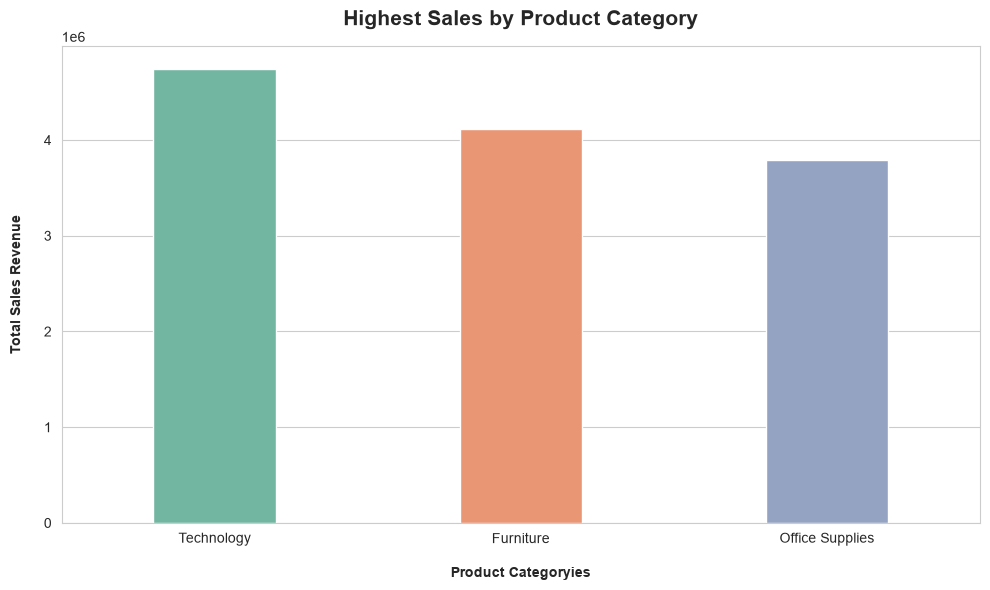

In [ ]:
plt.figure(figsize = (10, 6))

top_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending = False).reset_index()

sns.barplot(
    data = top_sales,
    y = "Sales",
    x = "Category",
    palette = "Set2",
    width = 0.4,
    errorbar = None,
    legend = False,
    hue = "Category"
)

plt.title("Highest Sales by Product Category", fontsize = 15, fontweight = "bold", pad = 15)

plt.xlabel("Product Categoryies", fontsize = 10, fontweight = "bold", labelpad = 15)
plt.ylabel("Total Sales Revenue", fontsize = 10, fontweight = "bold", labelpad = 15)

plt.tight_layout()


plt.savefig("../images/highest_sales_by_product_category.png", dpi = 300, bbox_inches = "tight")
plt.show()


### 📊 Key Observations

* **Highest Sales:** The **Technology** category generates the highest total sales compared to all other product categories.
* **Runner-up:** **Furniture** ranks as the second highest contributor to total sales.
* **Lowest Sales:** **Office Supplies** contributes the least to overall sales among the three categories.

**💡 Summary:** Overall, **Technology** products bring in the most sales revenue for the business, followed by **Furniture**, while **Office Supplies** stands at the bottom.


## 📈 Which Sub-Categories generate the highest total sales revenue?

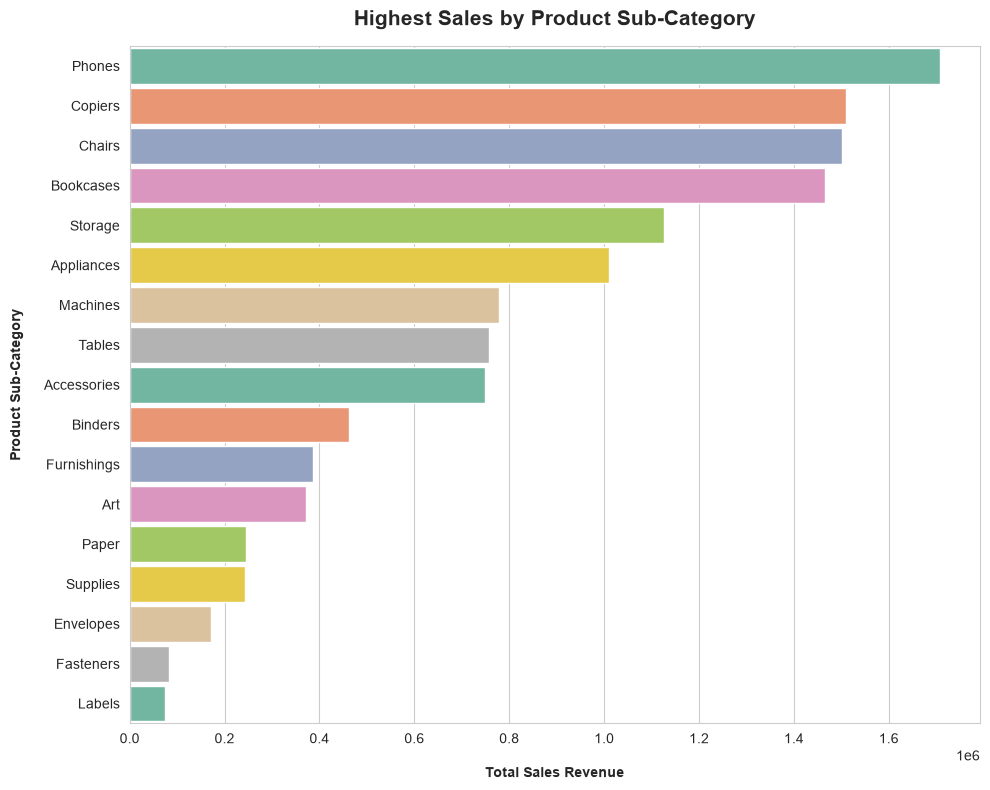

In [ ]:
plt.figure(figsize = (10, 8))


top_sub_categories = df.groupby("Sub.Category")["Sales"].sum().sort_values(ascending = False).reset_index()


sns.barplot(
    data = top_sub_categories,
    y = "Sub.Category",
    x = "Sales",
    palette = "Set2",
    hue = "Sub.Category",
    errorbar = None,
    legend = False,
    width = 0.9
)
plt.title("Highest Sales by Product Sub-Category", fontsize = 15, fontweight = "bold", pad = 15)

plt.ylabel("Product Sub-Category", fontsize = 10, fontweight = "bold", labelpad = 15)
plt.xlabel("Total Sales Revenue", fontsize = 10, fontweight = "bold", labelpad = 15)

plt.tight_layout()

plt.savefig("../images/highest_sales_by_product_sub-category.png", dpi = 300, bbox_inches = "tight")
plt.show()

### 📊 Key Observations

* **Top Performer:** The **Phones** sub-category achieves the highest total sales revenue among all items, followed closely by **Copiers** and **Chairs**.
* **Moderate Performers:** Sub-categories such as **Machines**, **Tables**, and **Accessories** sit in the middle, showing moderate sales performance.
* **Lowest Performers:** **Labels** contributes the least to the overall sales revenue, with **Fasteners** and **Envelopes** also ranking near the bottom.

**💡 Summary:** **Phones** and **Copiers** serve as the primary drivers of sales revenue, while small office stationery items like **Labels** and **Fasteners** bring in the lowest total sales.


## 🌍 Which countries contribute 80% of total sales?

In [52]:
all_countries = df.groupby("Country")["Sales"].sum().sort_values(ascending = False).reset_index()

top_Country = all_countries[all_countries["Sales"].cumsum()/all_countries["Sales"].sum() <=0.8]



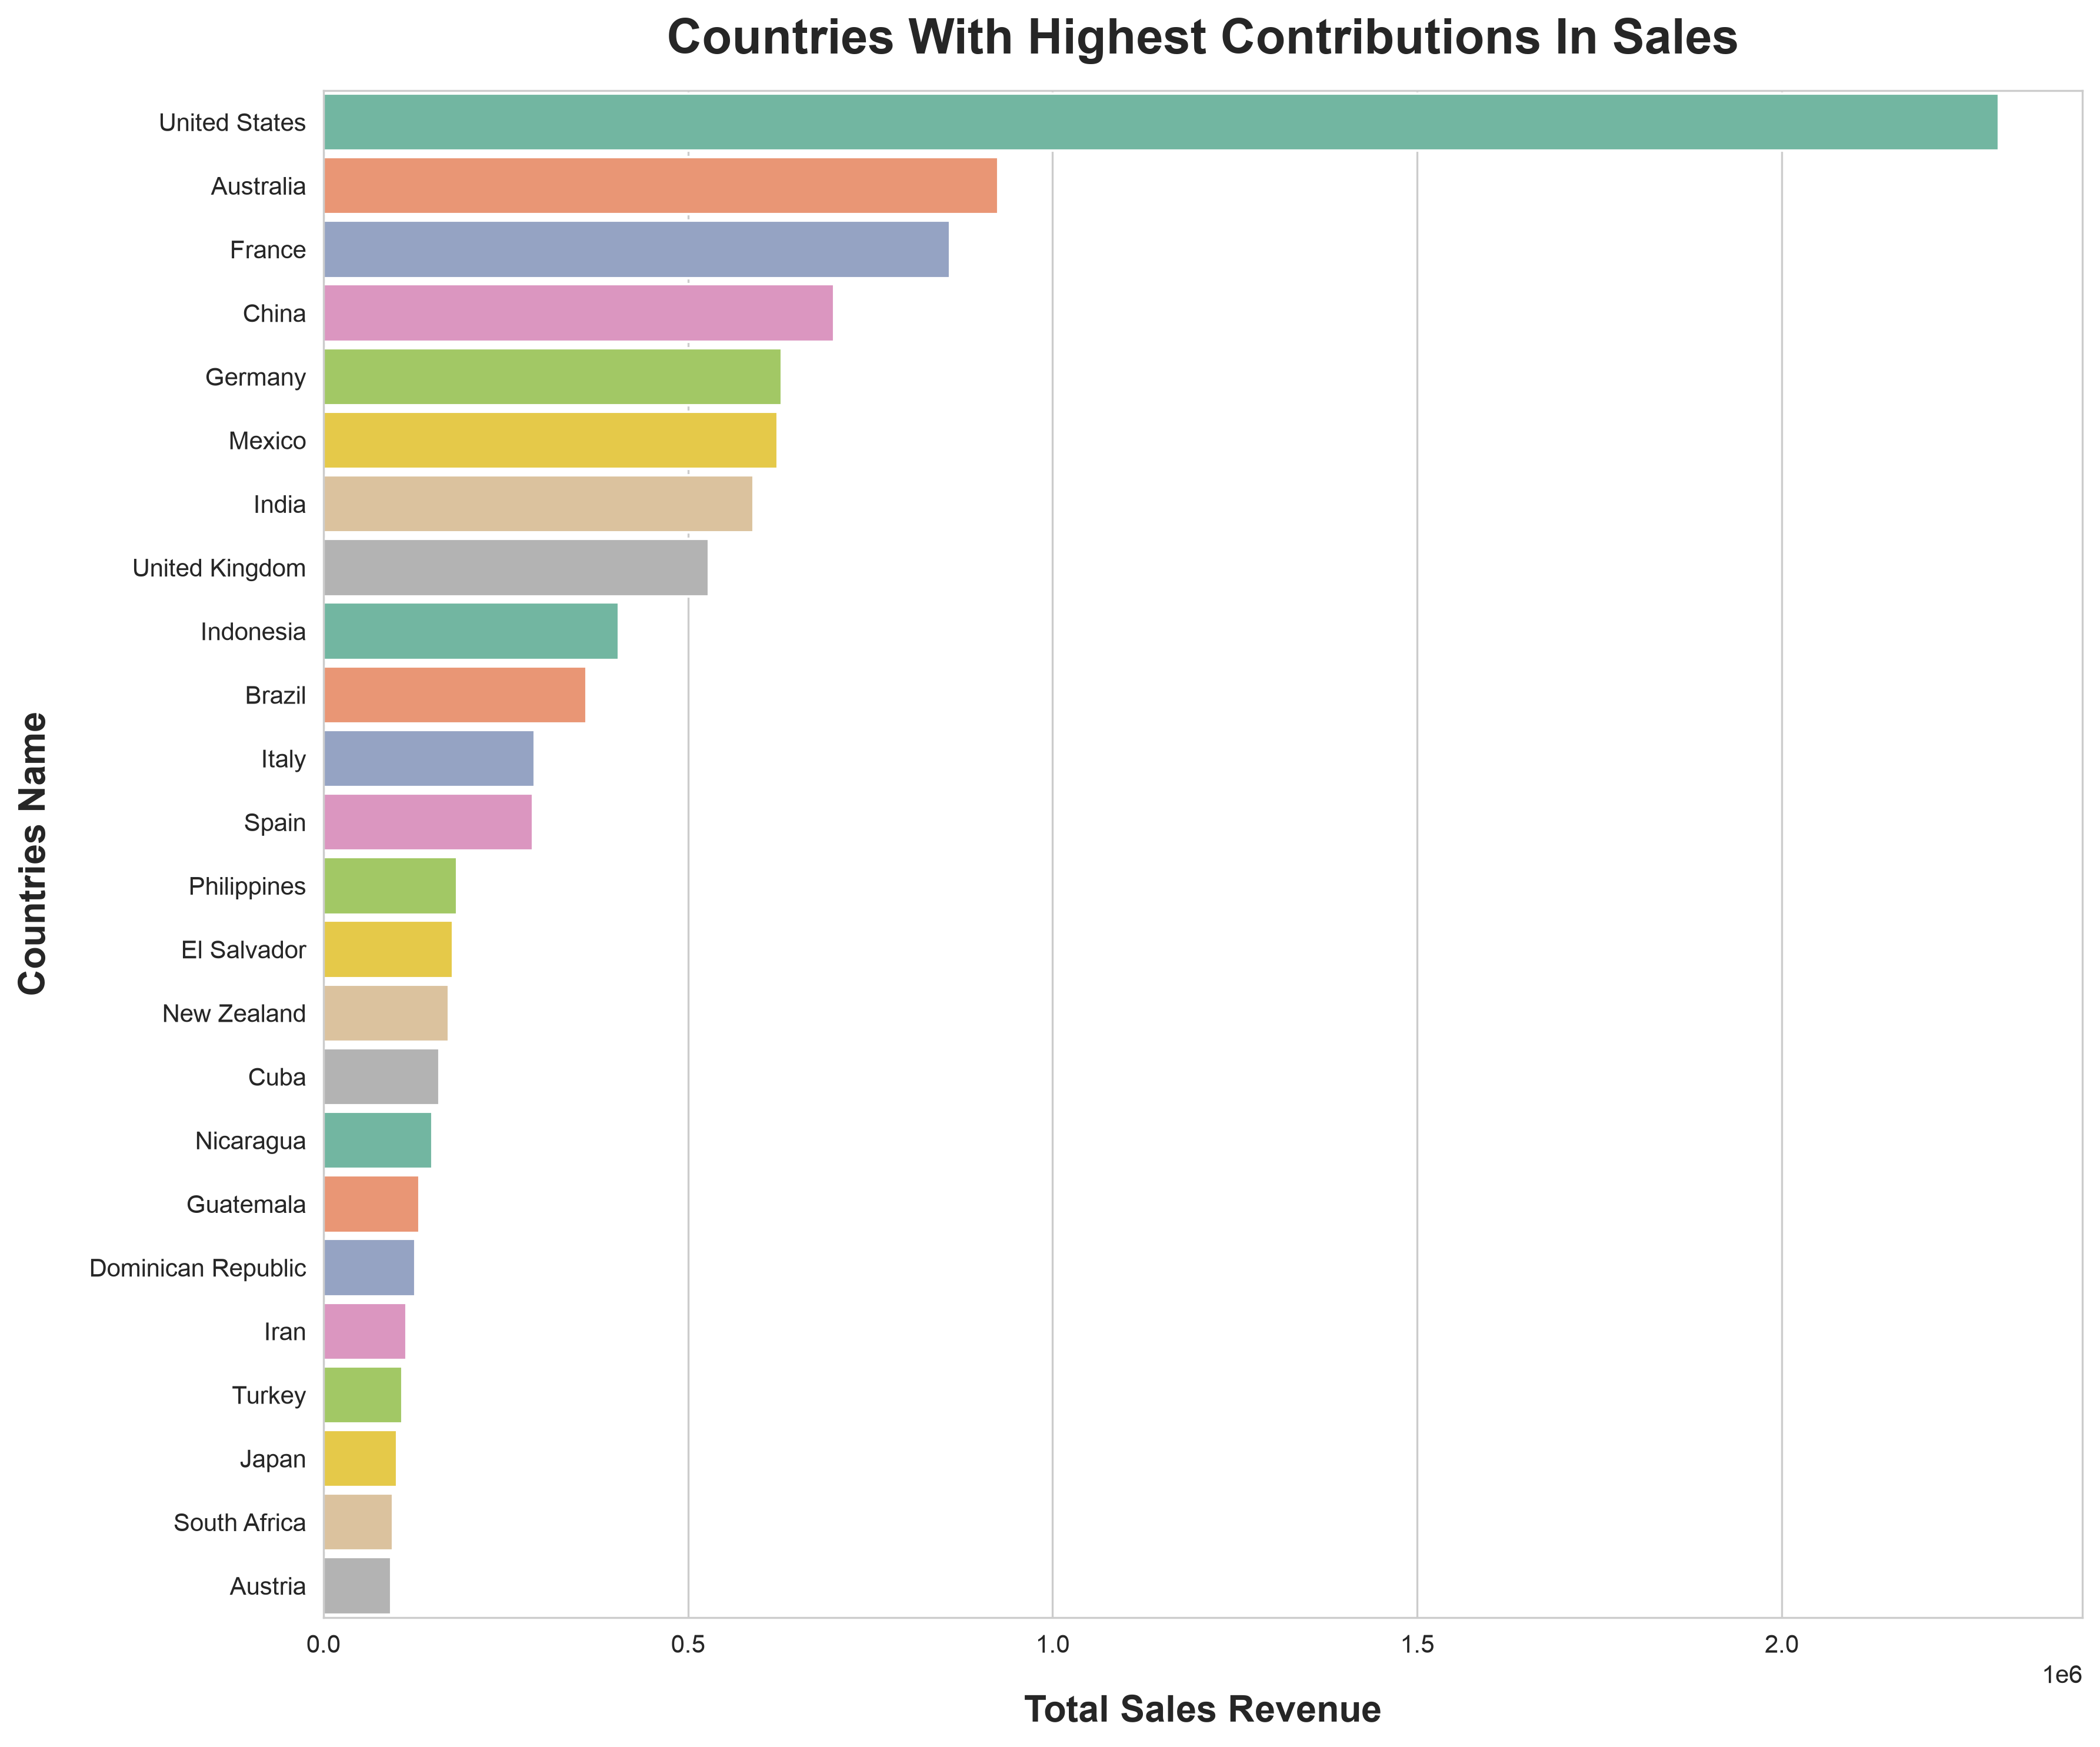

In [53]:
plt.figure(figsize = (12,10))

sns.barplot(
    data = top_Country,
    y = "Country",
    x = "Sales",
    hue = "Country",
    legend = False,
    palette = "Set2",
    errorbar = None,
    width = 0.9
)

plt.title("Countries With Highest Contributions In Sales", fontsize = 20, fontweight = "bold", pad = 15)

plt.xlabel("Total Sales Revenue", fontsize = 15, fontweight = "bold", labelpad = 15)
plt.ylabel("Countries Name", fontsize = 15, fontweight = "bold", labelpad = 15)

plt.tight_layout()

plt.savefig("../images/countries_with_highest_countribution_in_sales_bargraph.png", dpi = 300, bbox_inches = "tight")
plt.show()

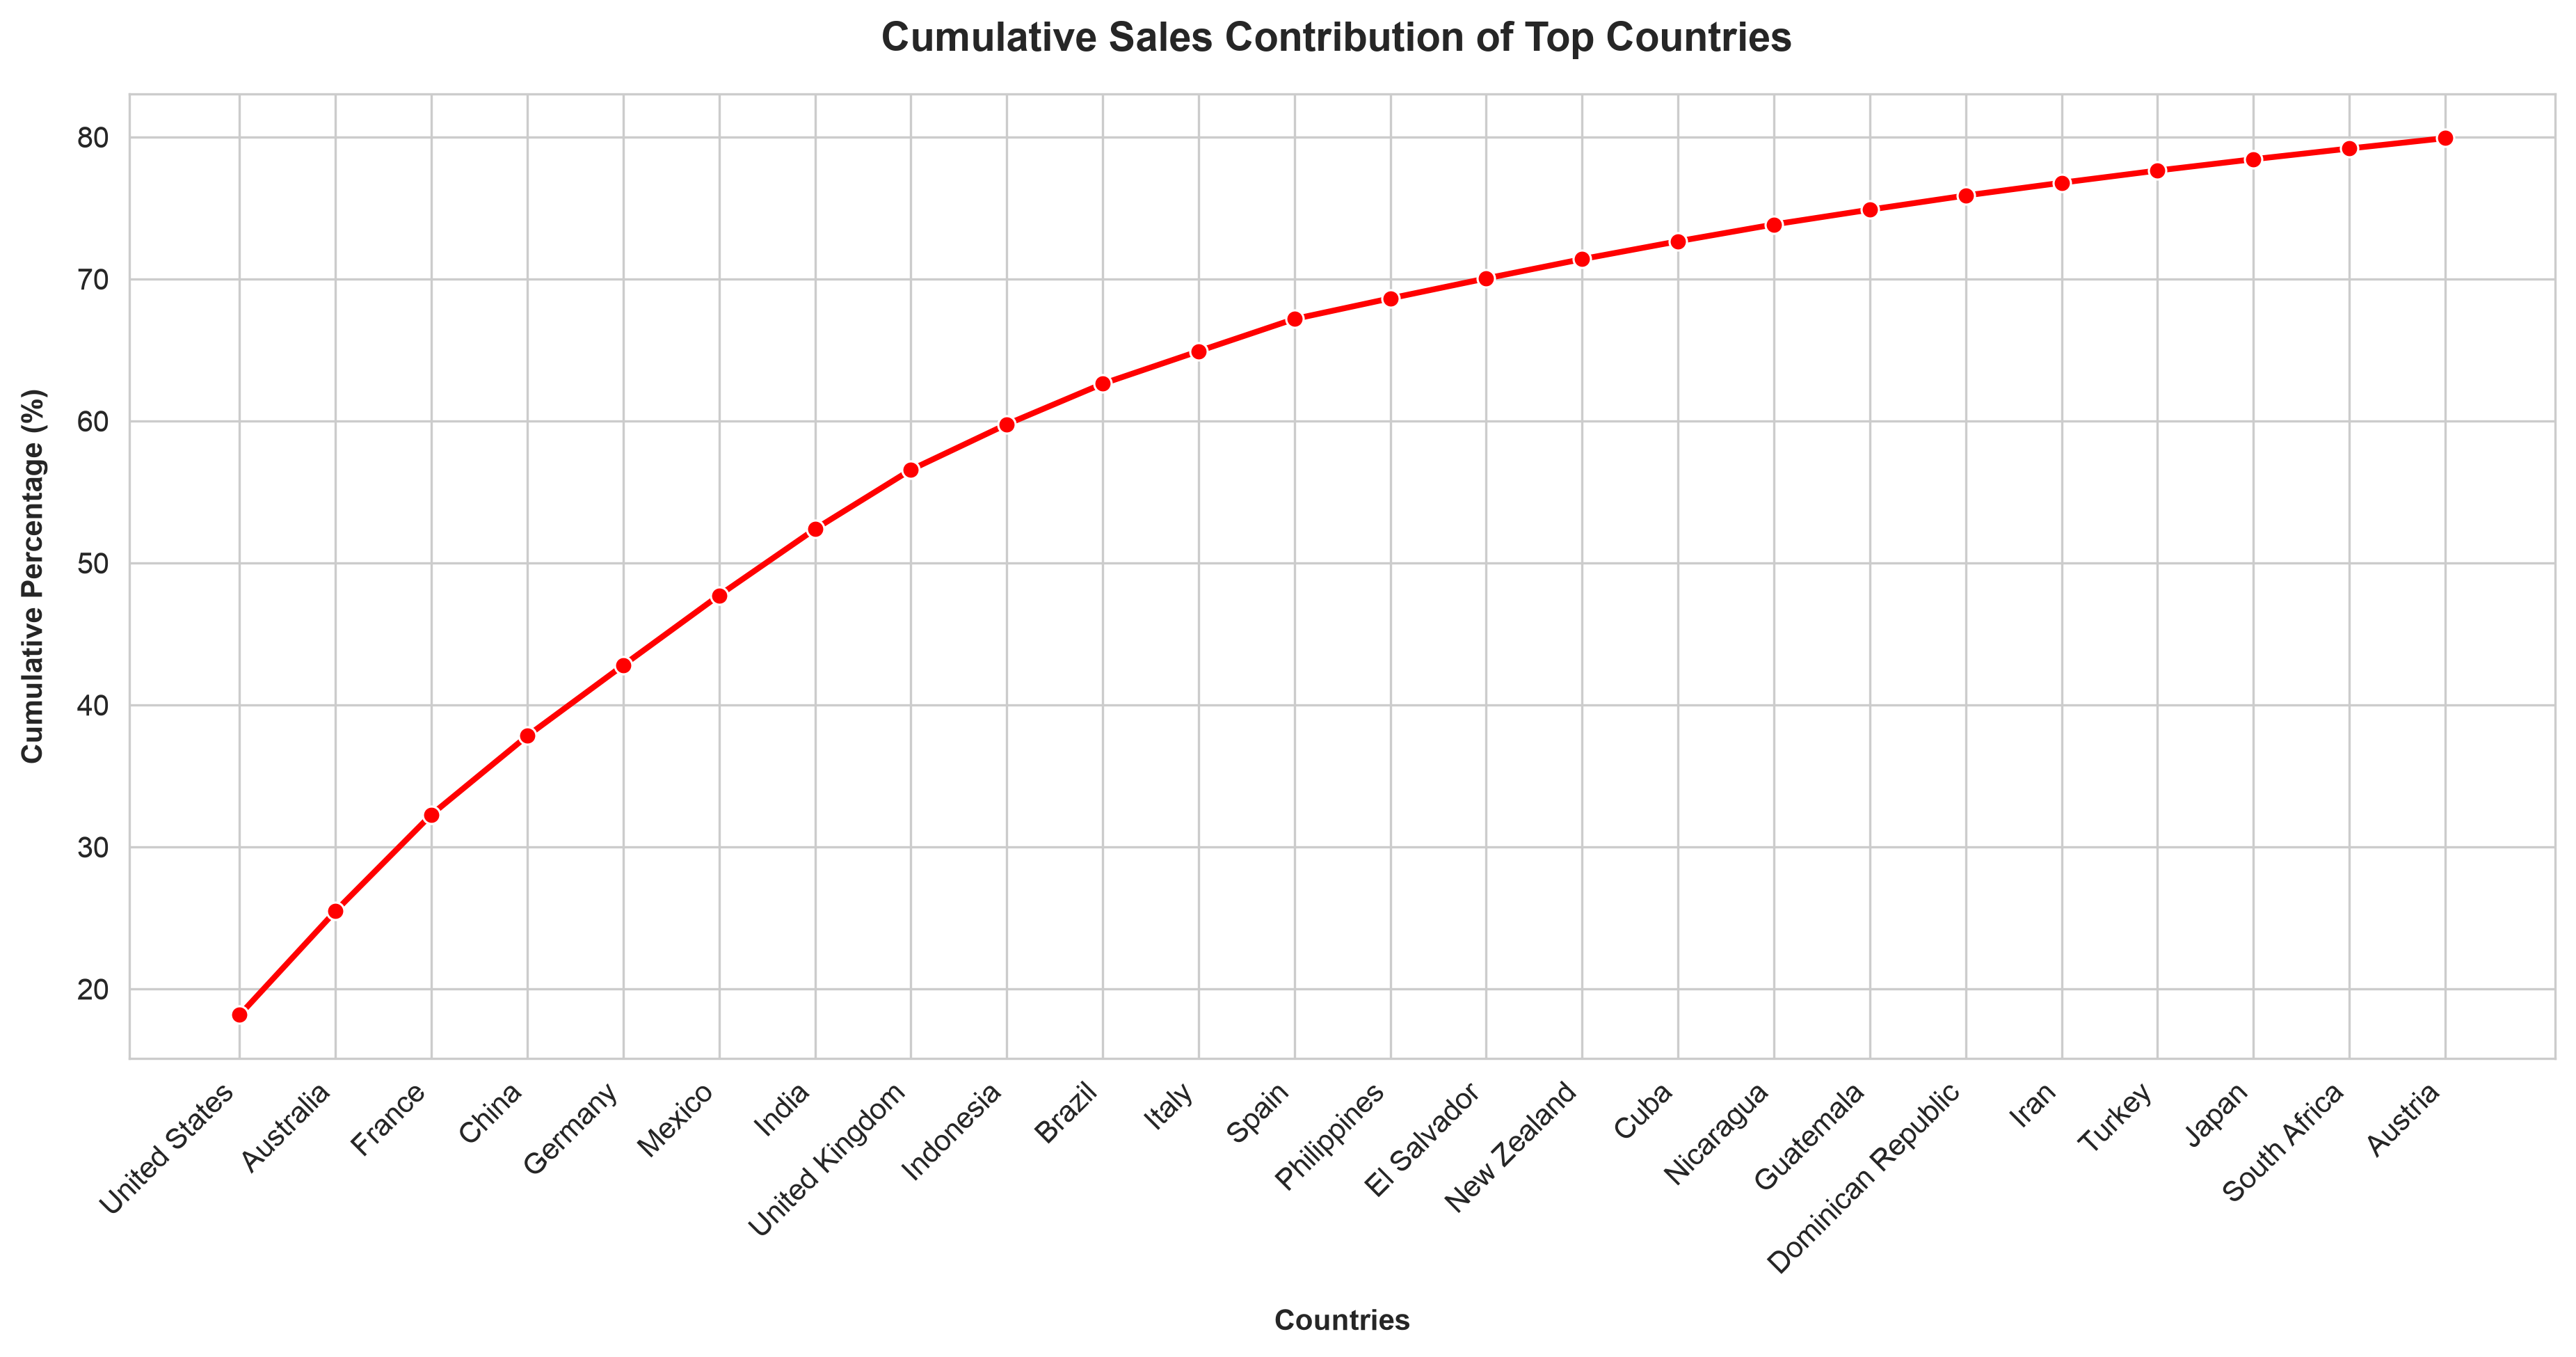

In [54]:
top_Country['Cum_Percentage'] = (top_Country['Sales'].cumsum() / df['Sales'].sum()) * 100

plt.figure(figsize=(15, 6))

sns.lineplot(
    data = top_Country,
    x = "Country",
    y = "Cum_Percentage",
    color = "red",
    marker = "o",
    linewidth = 2,
    sort = False
)

plt.title("Cumulative Sales Contribution of Top Countries ", fontsize=14, fontweight="bold", pad=15)

plt.xlabel("Countries", fontsize=10, fontweight="bold", labelpad=10)
plt.ylabel("Cumulative Percentage (%)", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha='right')

plt.savefig("../images/countries_with_highest_countribution_in_sales_linegraph.png", dpi = 300, bbox_inches = "tight")

plt.show()

### 📊 Key Observations (Cumulative Sales Contribution)

* **Concentrated Revenue:** The curve climbs very sharply in the beginning, showing that the first few global markets generate the largest portion of sales revenue.
* **Steady Progression:** As the line moves through European, Asian, and Latin American countries, the growth rate slows down, showing smaller but steady increments to the total business.
* **Target Threshold:** The line ends exactly at the point where the collective contribution of these listed countries fulfills the required eighty percent milestone of overall sales.

**💡 Summary:** Global sales are highly dependent on a core set of major international countries, making them the primary markets to focus on for baseline revenue security.


## 💸 🆚 🧾 Profit vs Sales

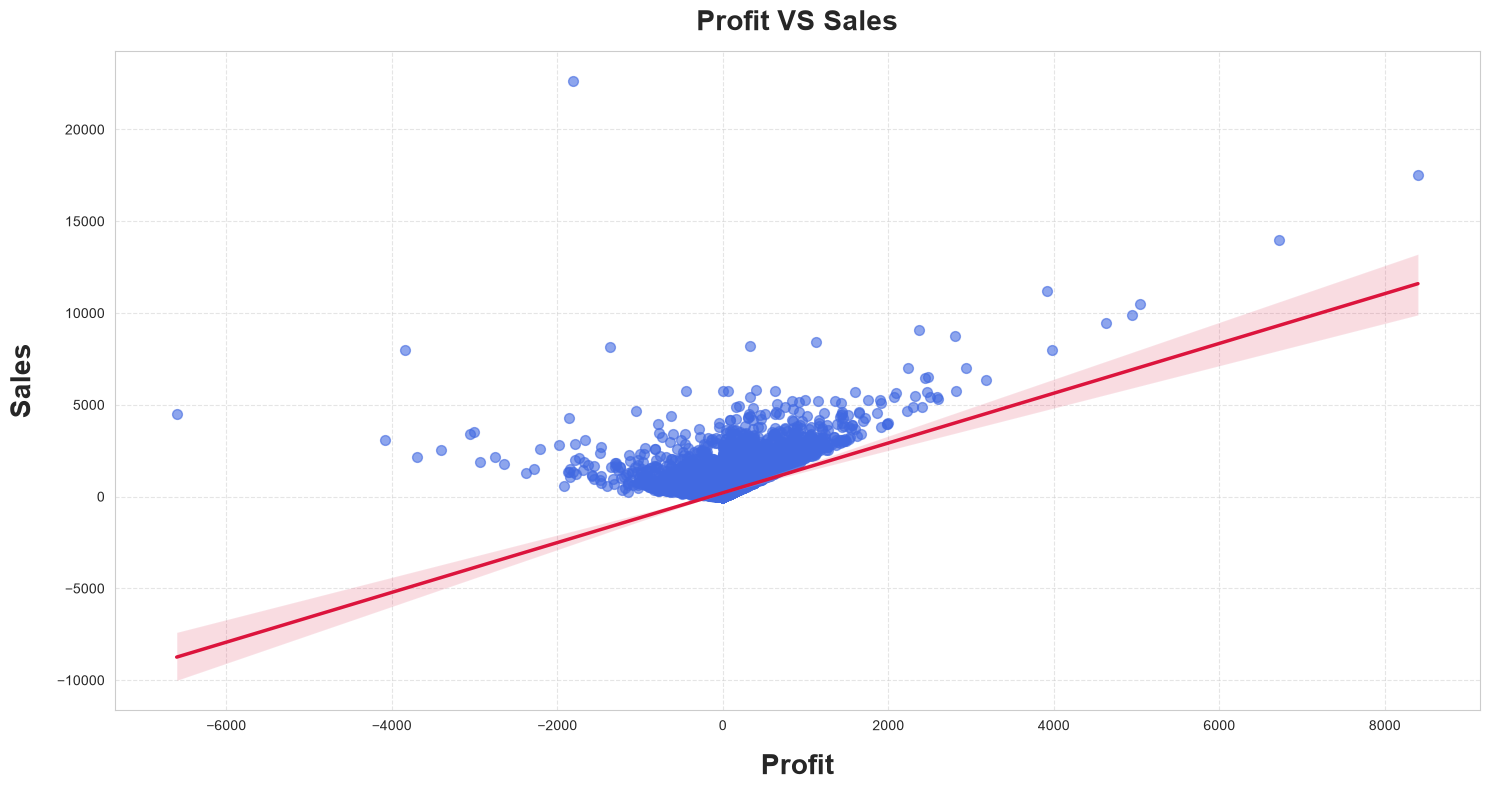

In [ ]:
plt.figure(figsize = (15, 8))

sns.regplot(
    data = df,
    x = "Profit",
    y = "Sales",
    scatter_kws={"color": "royalblue", "alpha": 0.6, "s": 50}, 
    line_kws={"color": "crimson", "linewidth": 2.5}
)

plt.title("Profit VS Sales", fontsize = 20, fontweight = "bold", pad = 15)

plt.xlabel("Profit", fontsize = 20, fontweight = "bold", labelpad = 15)
plt.ylabel("Sales", fontsize = 20, fontweight = "bold", labelpad = 15)

plt.grid(True, linestyle = "--", alpha = 0.5)
plt.tight_layout()

plt.savefig("../images/profit_vs_sales.png", dpi = 300, bbox_inches = "tight")
plt.show()

### 📊 Key Observations (Profit vs Sales Trend)

* **General Trend:** The regression line indicates a positive relationship overall, suggesting that higher sales generally move along with positive profit margins.
* **Loss-Making Zones:** The scatter points extending to the left show that high revenue or large sales do not always guarantee a profit, as some major transactions still result in notable losses.
* **Core Concentration:** A dense cluster of transactions sits around the zero-profit baseline, showing that a significant volume of sales generates low to balanced returns before hitting higher margins.

**💡 Summary:** While increasing sales generally supports higher profitability, close monitoring is required for high-revenue transactions that cross into negative profit territories.


## 🧾 🆚 💸 Discount vs Profit

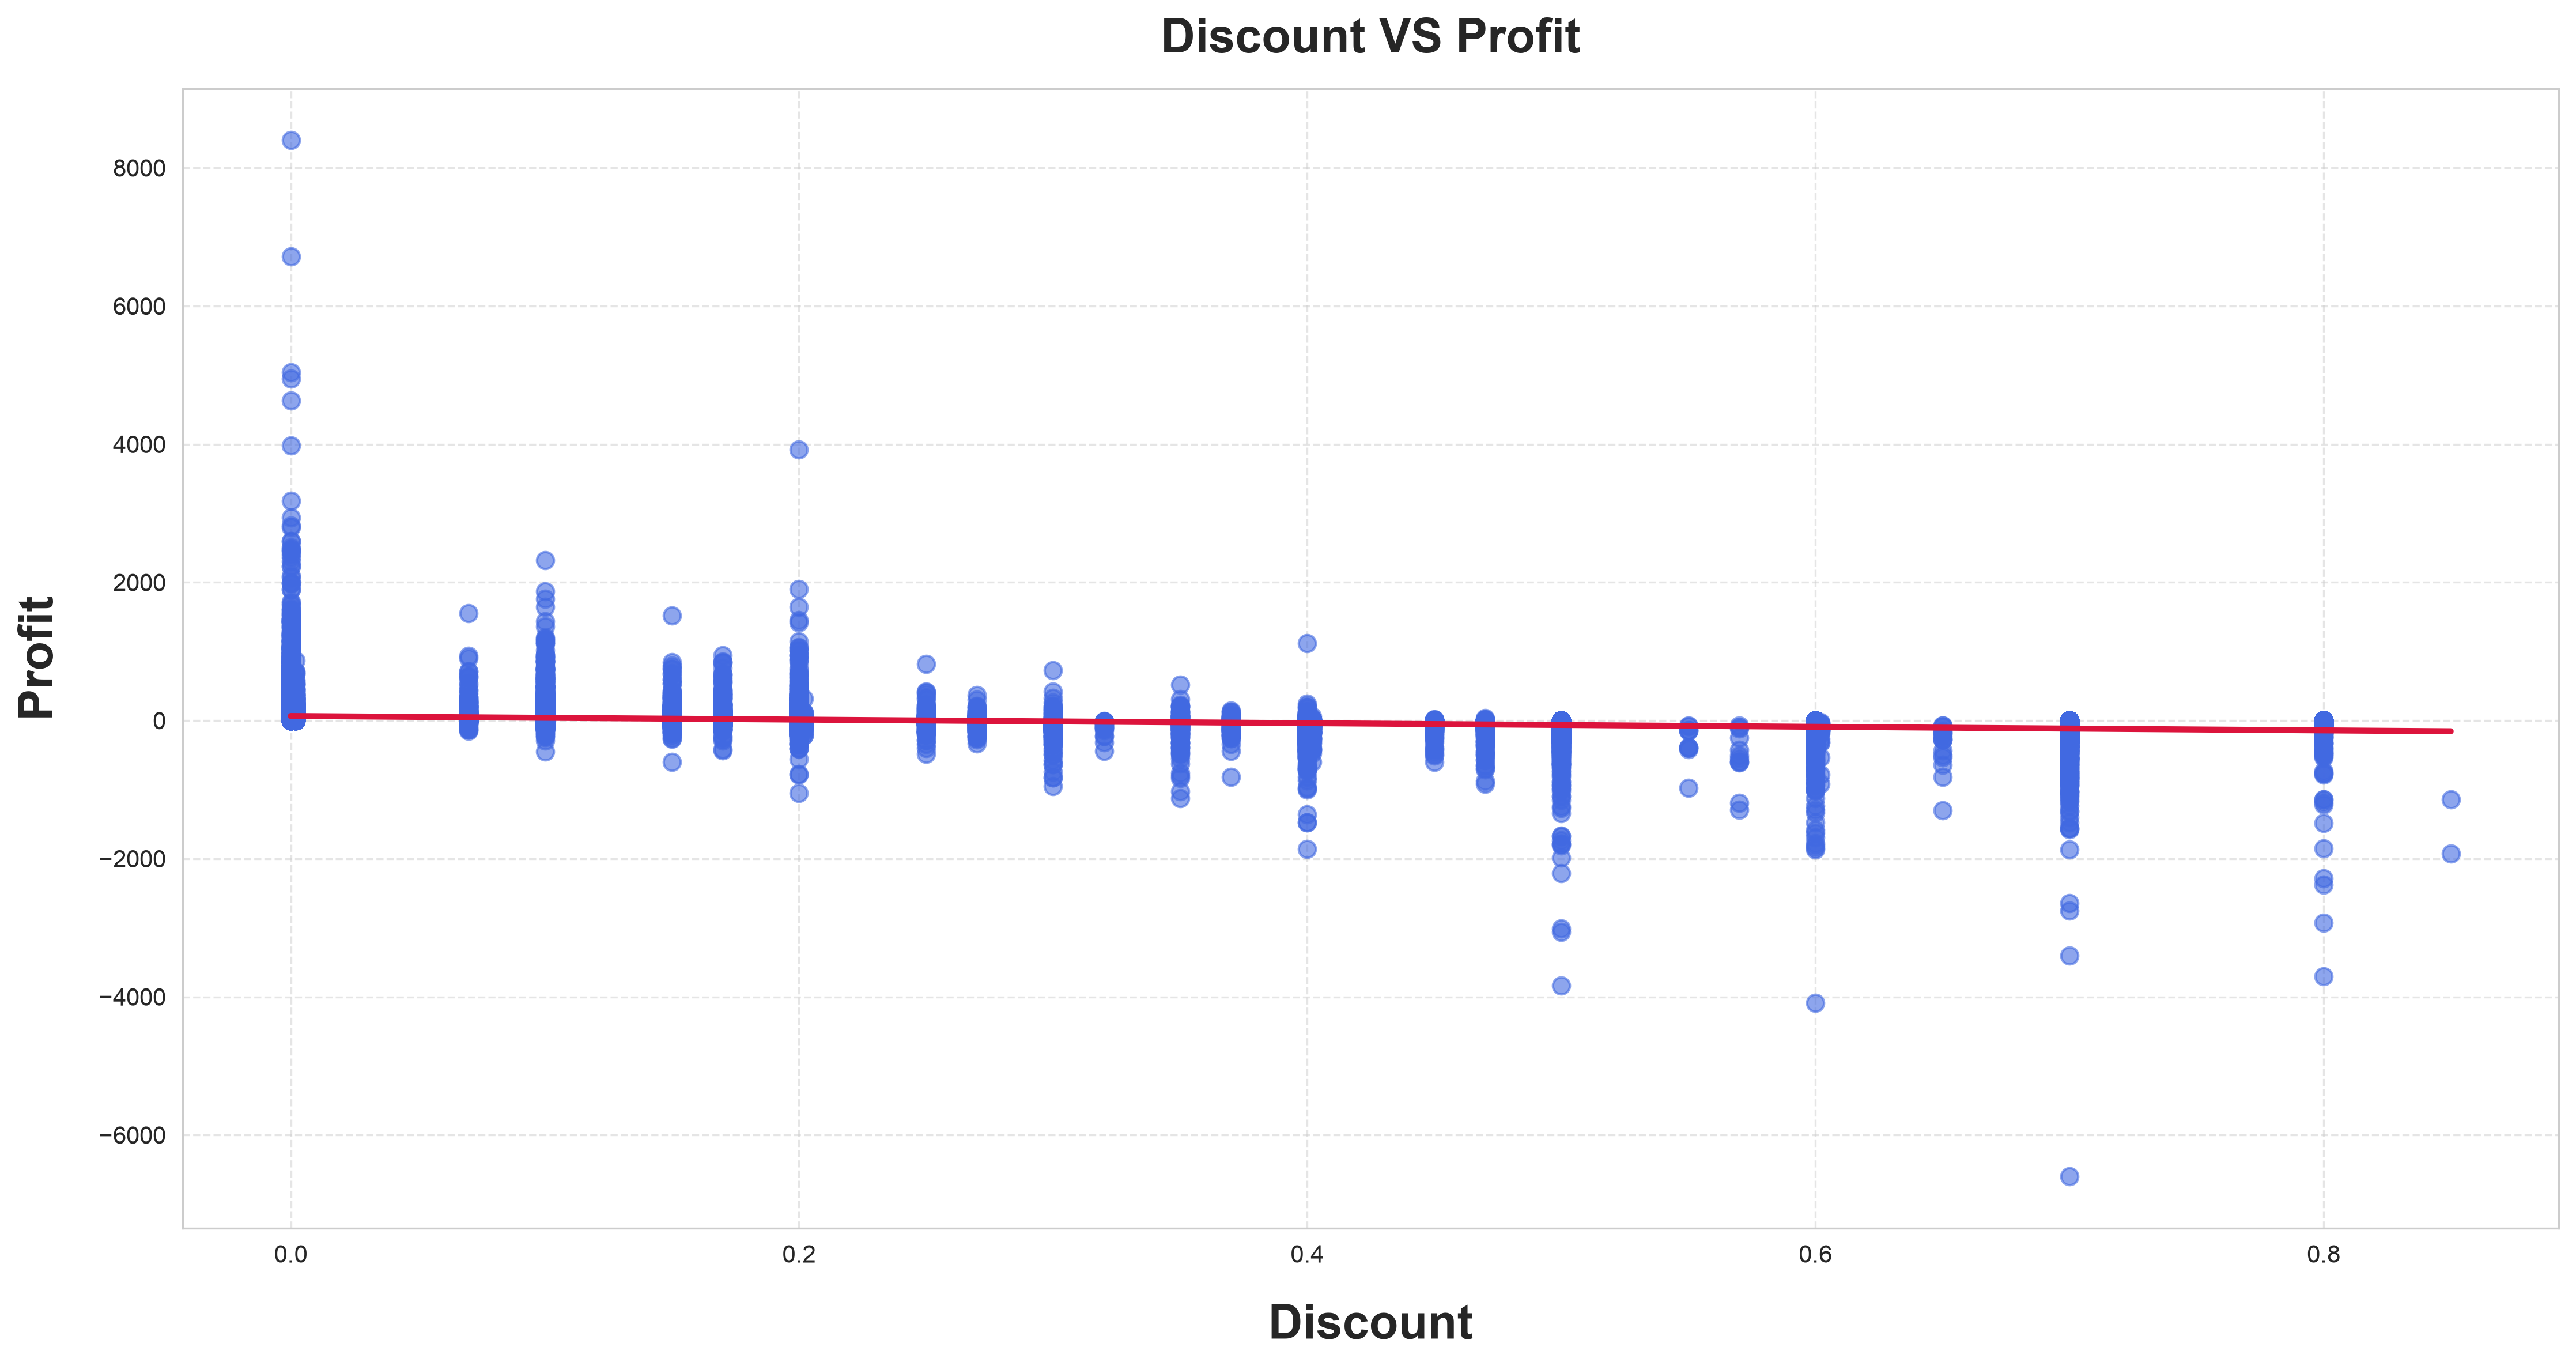

In [17]:
plt.figure(figsize = (15, 8))

sns.regplot(
    data = df,
    x = "Discount",
    y = "Profit",
    scatter_kws={"color": "royalblue", "alpha": 0.6, "s": 50}, 
    line_kws={"color": "crimson", "linewidth": 2.5}
)

plt.title("Discount VS Profit", fontsize = 20, fontweight = "bold", pad = 15)

plt.xlabel("Discount", fontsize = 20, fontweight = "bold", labelpad = 15)
plt.ylabel("Profit", fontsize = 20, fontweight = "bold", labelpad = 15)

plt.grid(True, linestyle = "--", alpha = 0.5)
plt.tight_layout()

plt.savefig("../images/discount_vs_profit.png", dpi = 300, bbox_inches = "tight")
plt.show()

### 📊 Key Observations (Discount vs Profit Trend)

* **Impact of Discounts:** The downward slope of the regression line clearly shows a negative relationship, meaning that giving higher discounts generally leads to lower profit margins.
* **Profitability at Zero Discount:** The transactions with no discounts applied show a high concentration of positive profits, including some of the largest gains for the business.
* **Loss-Making Danger Zone:** As the discount rate increases, more data points spread deep into the negative territory, indicating that heavy discounting frequently triggers notable financial losses.

**💡 Summary:** Offering high discounts is heavily linked to falling profits and increased losses, suggesting the need for a more controlled pricing policy.


## 📈📉 Monthly Sales Trend

In [55]:
# Convert Order.Date into datetime
df["Order.Date"] = pd.to_datetime(df["Order.Date"])

# Finding Month frome Order.Date
df["Month"] = df["Order.Date"].dt.month


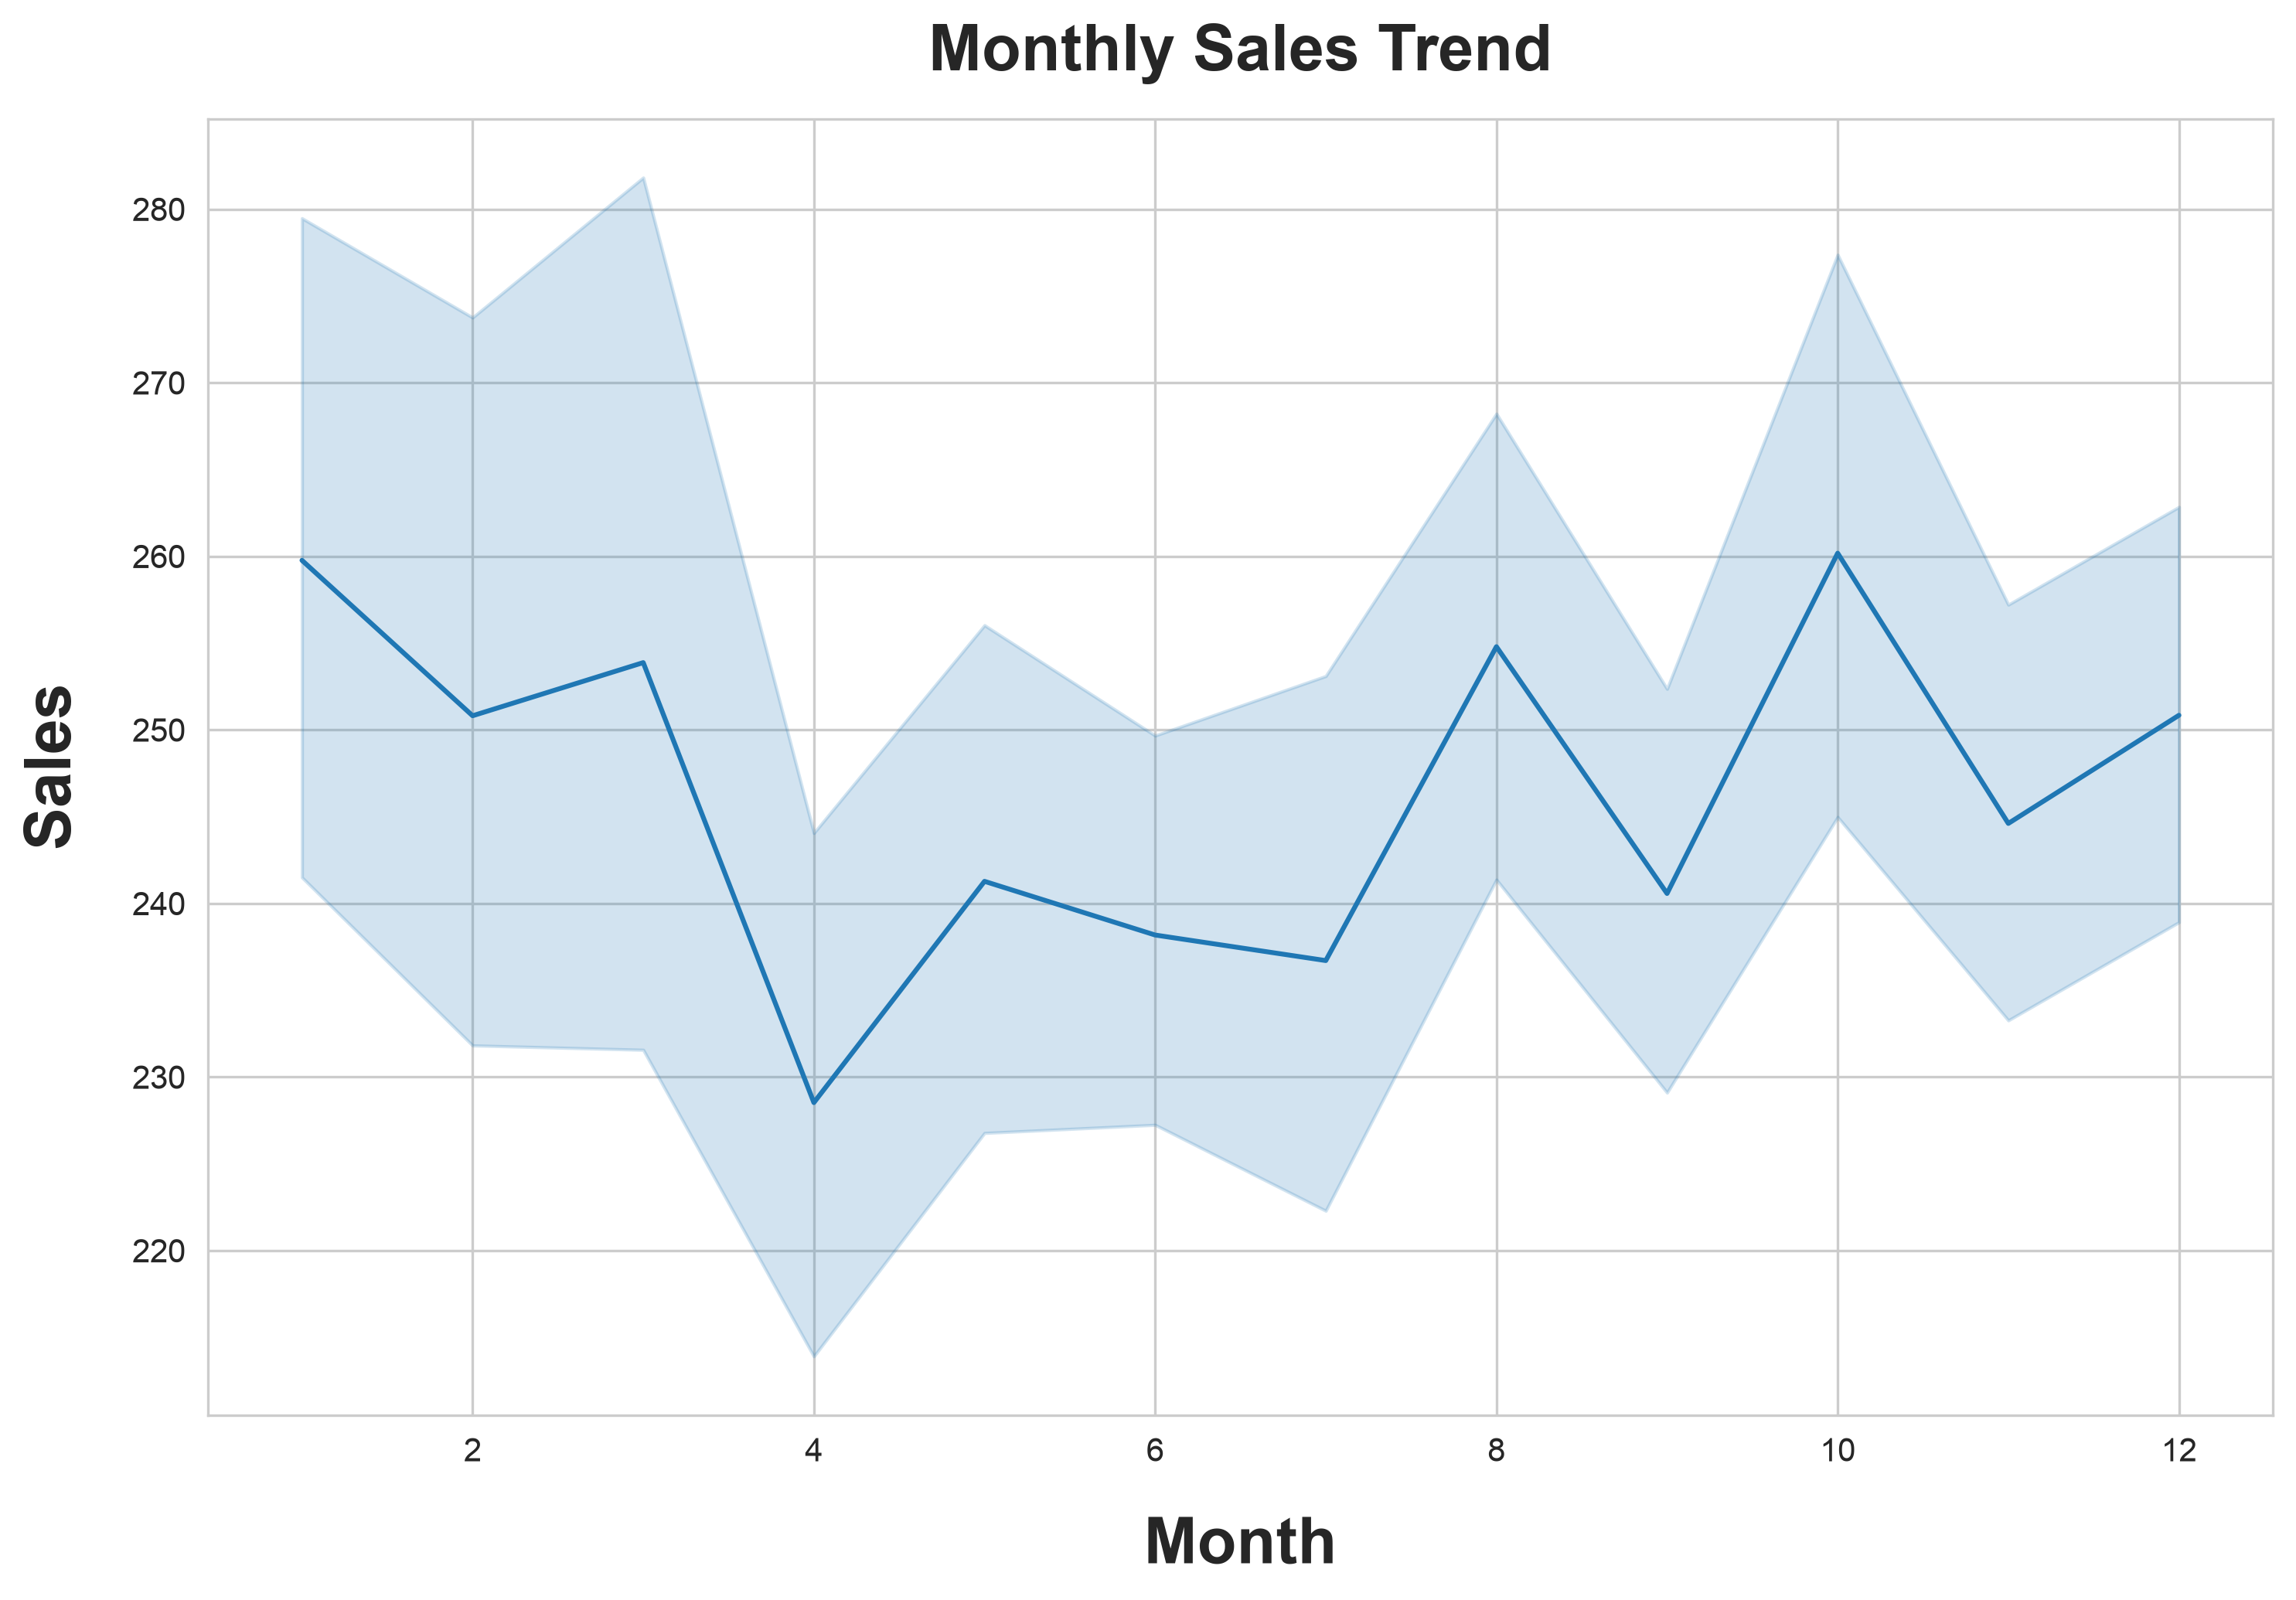

In [56]:
plt.figure(figsize = (10, 7))

sns.lineplot(
    data = df,
    x = "Month",
    y = "Sales",
)
plt.title("Monthly Sales Trend", fontsize = 20, fontweight = "bold", pad = 15)

plt.xlabel("Month", fontsize = 20, fontweight = "bold", labelpad = 15)
plt.ylabel("Sales", fontsize = 20, fontweight = "bold", labelpad = 15)

plt.tight_layout()

plt.savefig("../images/monthly_sales_trend.png", dpi = 300, bbox_inches = "tight")
plt.show()


### 📊 Key Observations (Monthly Sales Trend)

* **Initial Drop:** The trend line indicates a noticeable decrease in sales revenue during the early months of the year, hitting its lowest point around the fourth month.
* **Mid-Year Recovery:** Following the initial decline, sales perform relatively steady before climbing into seasonal peaks during the later parts of the year.
* **Fluctuating Waves:** The overall pattern reveals regular ups and downs across the months, showing distinct seasonal changes in customer buying behavior.

**💡 Summary:** Sales revenue moves in a cyclical wave throughout the year, suggesting that inventory and marketing efforts should be aligned to support high-demand periods in the second half of the year.


## 💰 Monthly Profit Trend

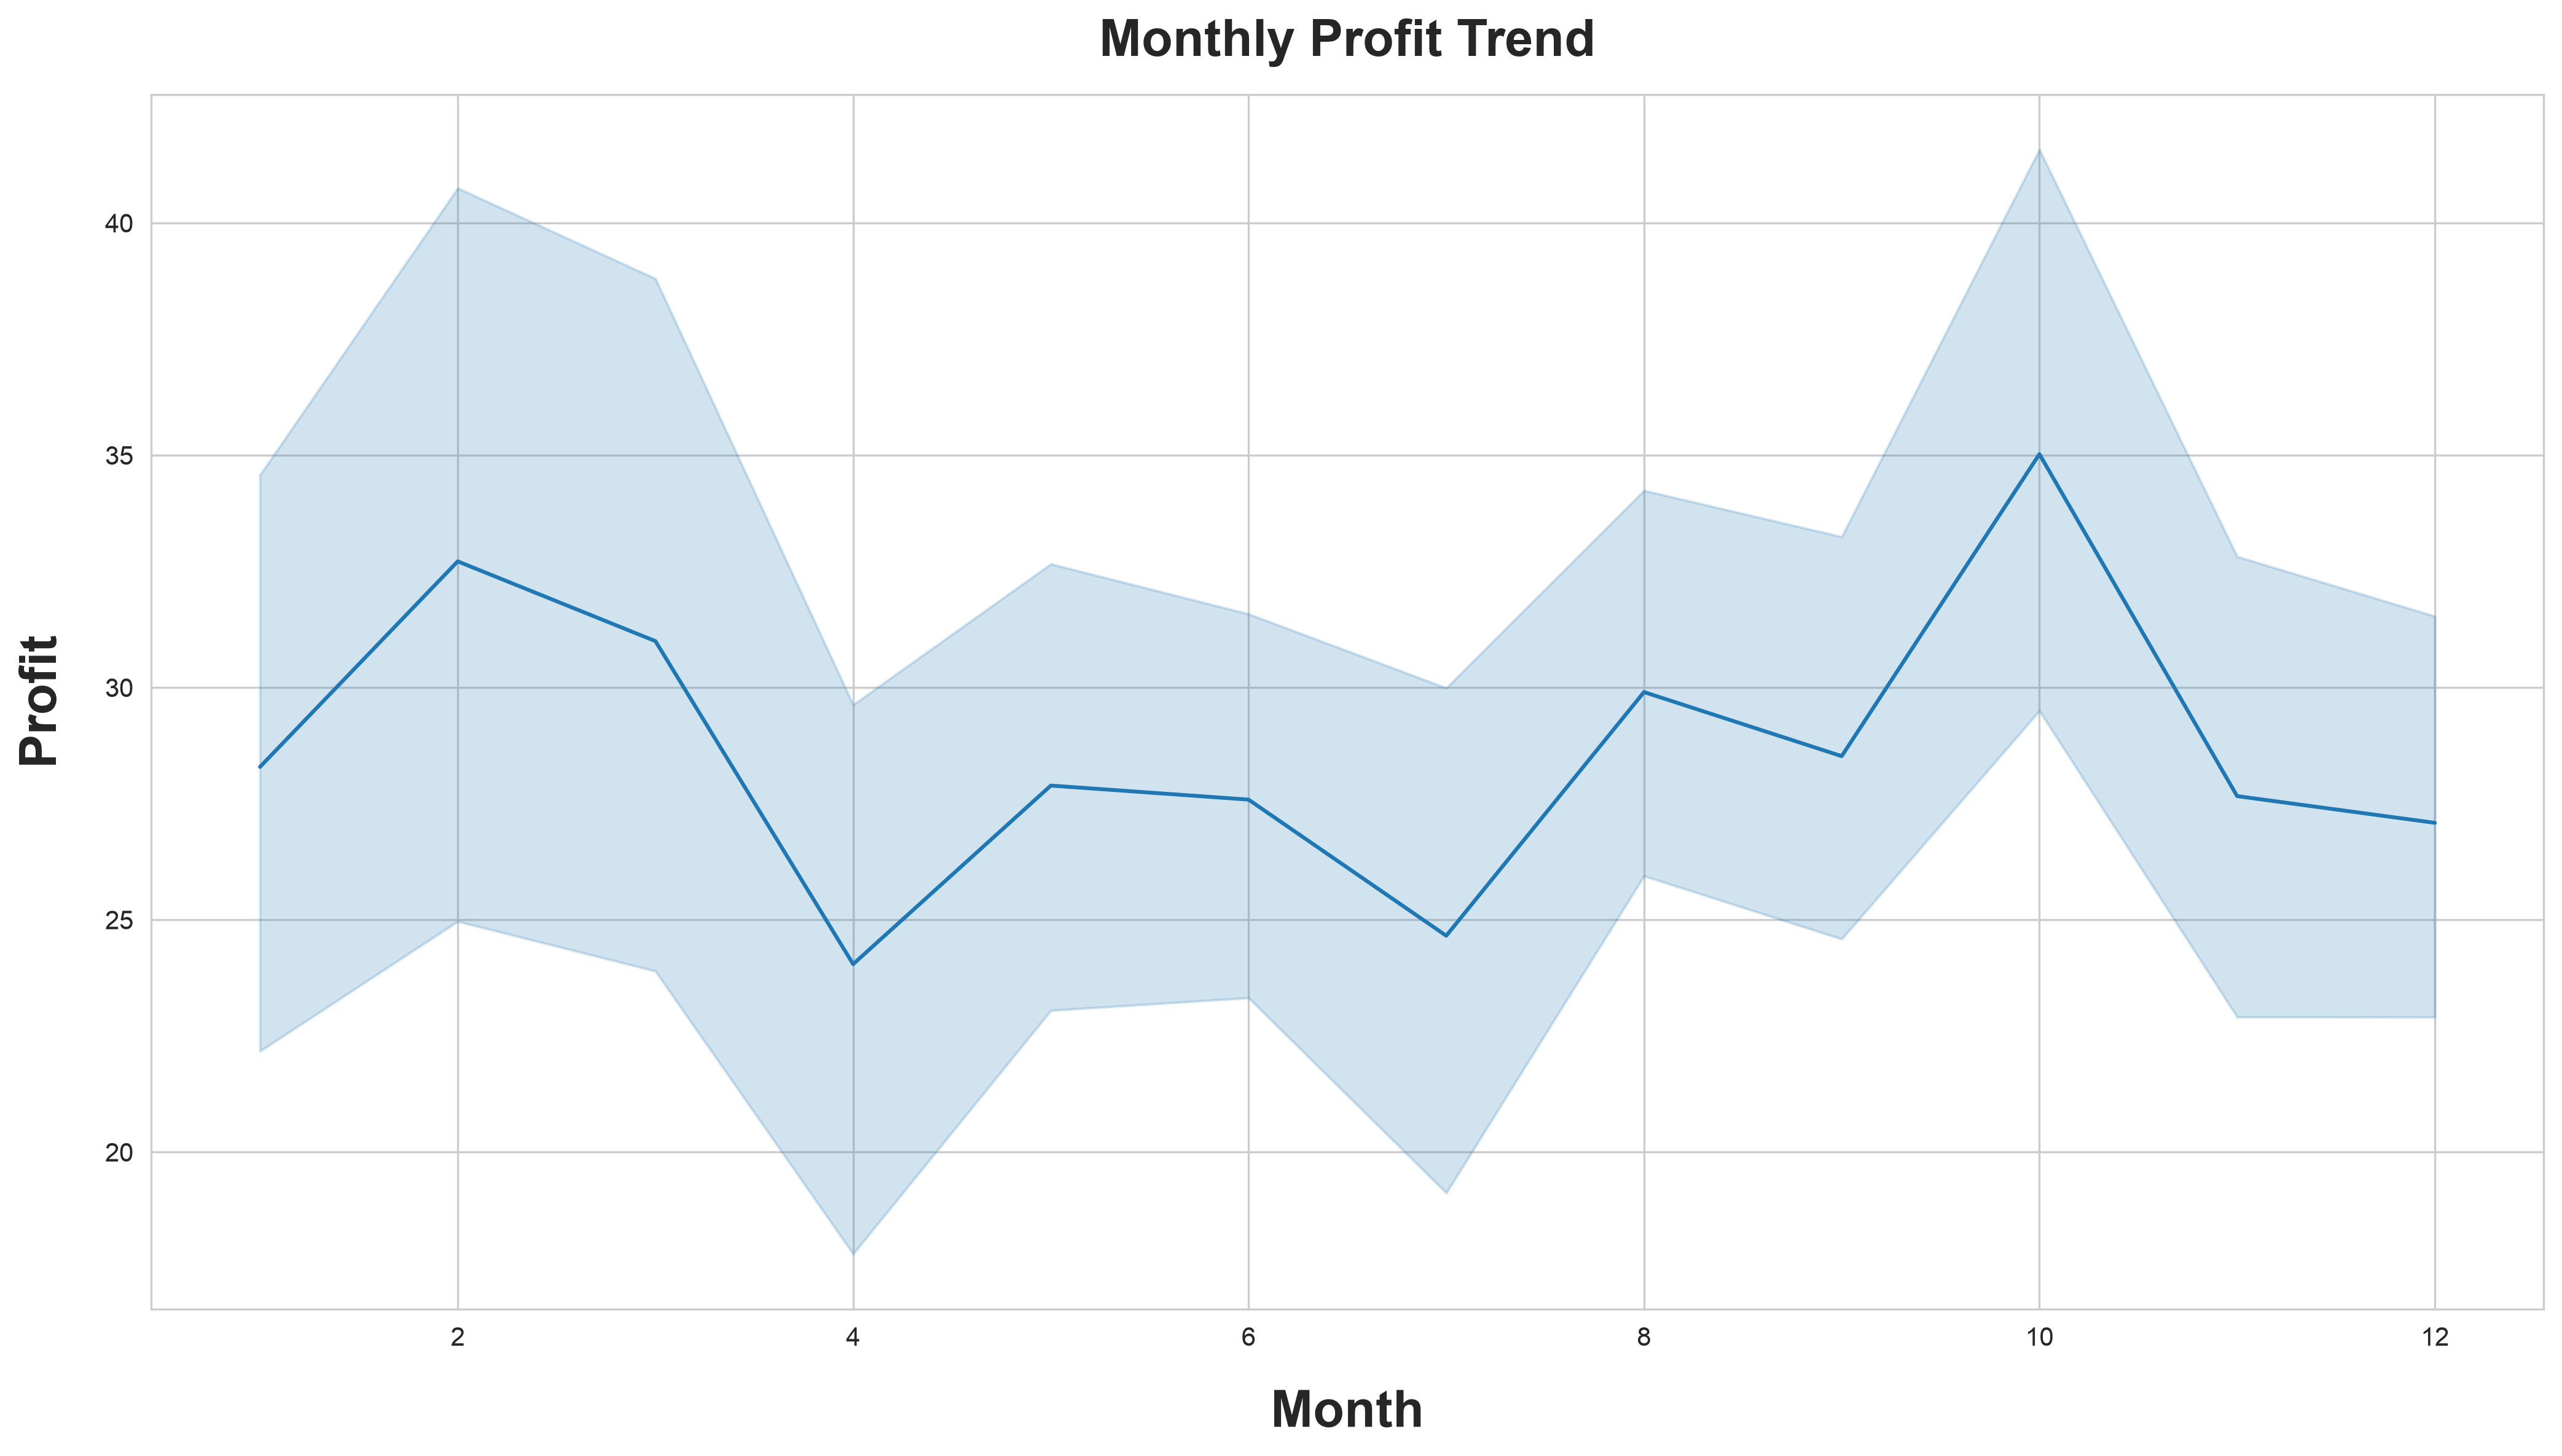

In [20]:
plt.figure(figsize = (14, 8))

sns.lineplot(
    data = df,
    x = "Month",
    y = "Profit",
)
plt.title("Monthly Profit Trend", fontsize = 20, fontweight = "bold", pad = 15)

plt.xlabel("Month", fontsize = 20, fontweight = "bold", labelpad = 15)
plt.ylabel("Profit", fontsize = 20, fontweight = "bold", labelpad = 15)

plt.tight_layout()

plt.savefig("../images/monthly_profit_trend.png", dpi = 300, bbox_inches = "tight")
plt.show()

### 📊 Key Observations (Monthly Profit Trend)

* **Initial Peak and Dip:** The profit line shows an early rise followed by a sharp drop, hitting a notable low point around the fourth month of the year.
* **Strongest Growth Month:** Profit margins bounce back significantly later in the year, reaching the absolute highest peak of performance during the tenth month.
* **Year-End Stabilization:** After the major late-year peak, profit performance drops again and stabilizes towards the final months, moving back to its average baseline.

**💡 Summary:** Profitability follows a wave-like seasonal cycle with clear peak periods, suggesting that business operations should focus maximum resources to capture the high-margin windows detected in the later half of the year.


## 📉 Top Loss Making Products

In [57]:
# Sorting all lossing making products
loss_making_products = df.groupby("Product.Name")["Profit"].sum().sort_values(ascending = True).reset_index()

# Top 10 loss making products
top_10_loss_making_product = loss_making_products.head(10)


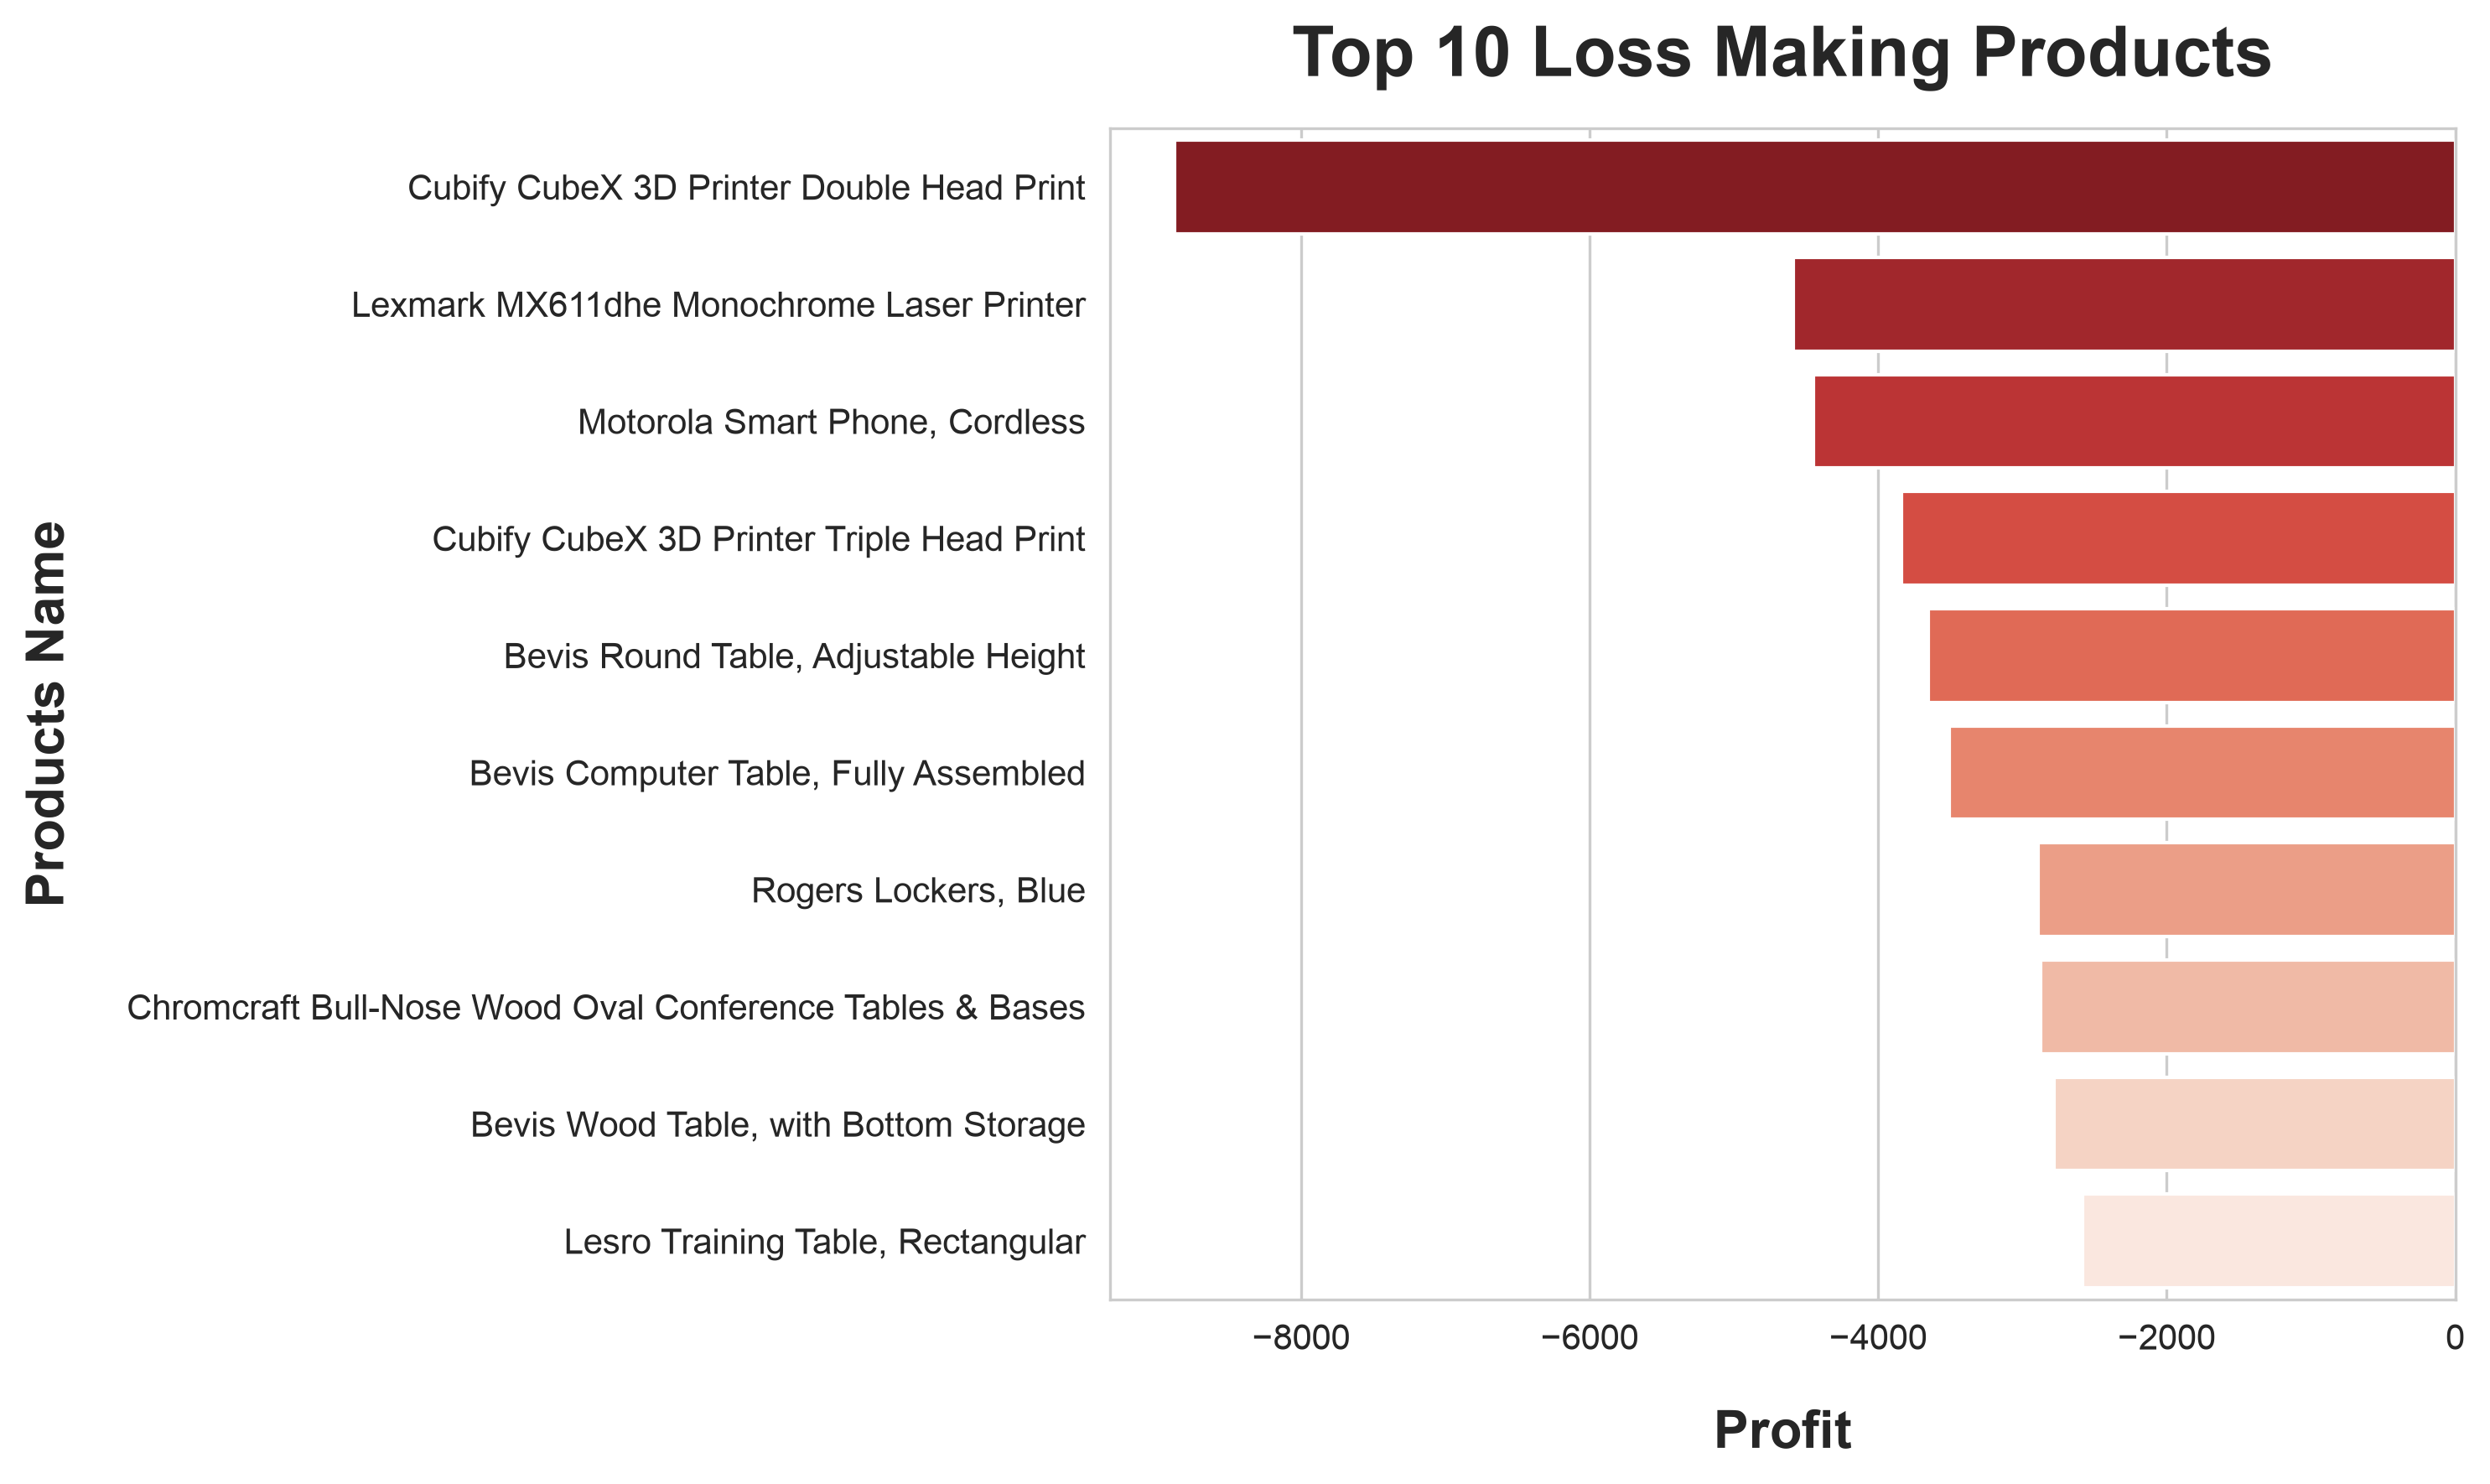

In [29]:
plt.figure(figsize = (10, 6))

sns.barplot(
    data = top_10_loss_making_product,
    x = "Profit",
    y = "Product.Name",
    errorbar = None,
    legend = False,
    palette = "Reds_r",
    hue = "Product.Name"
)

plt.title("Top 10 Loss Making Products", fontsize = 20, fontweight = "bold", pad = 15)

plt.xlabel("Profit", fontsize = 15, fontweight = "bold", labelpad = 15)
plt.ylabel("Products Name", fontsize = 15, fontweight = "bold", labelpad = 15)

plt.tight_layout()

plt.savefig("../images/top_10_loss_making_products.png", dpi = 300, bbox_inches = "tight")
plt.show()

### 📊 Key Observations (Top 10 Loss-Making Products)

* **Highest Financial Loss:** The 3D printer model stands out at the top of the chart as the item causing the most severe financial loss for the business.
* **Category Vulnerability:** Printers, smart phones, and various office furniture pieces like conference and training tables make up the majority of this worst-performing list.
* **Gradual Decline:** While the top item shows an exceptionally large drop into negative territory, the remaining products maintain a steady pattern of notable losses across the board.

**💡 Summary:** High-value technology items and bulky furniture pieces are currently driving the largest losses, pointing to a critical need to adjust their discount limits or delivery strategies.


## 📈 Top Profit Products

In [58]:
# Sorting all profit making products
profit_making_products = df.groupby("Product.Name")["Profit"].sum().sort_values(ascending = False).reset_index()

# Finding top 10 profit making products
top_10_profit_making_product = profit_making_products.head(10)

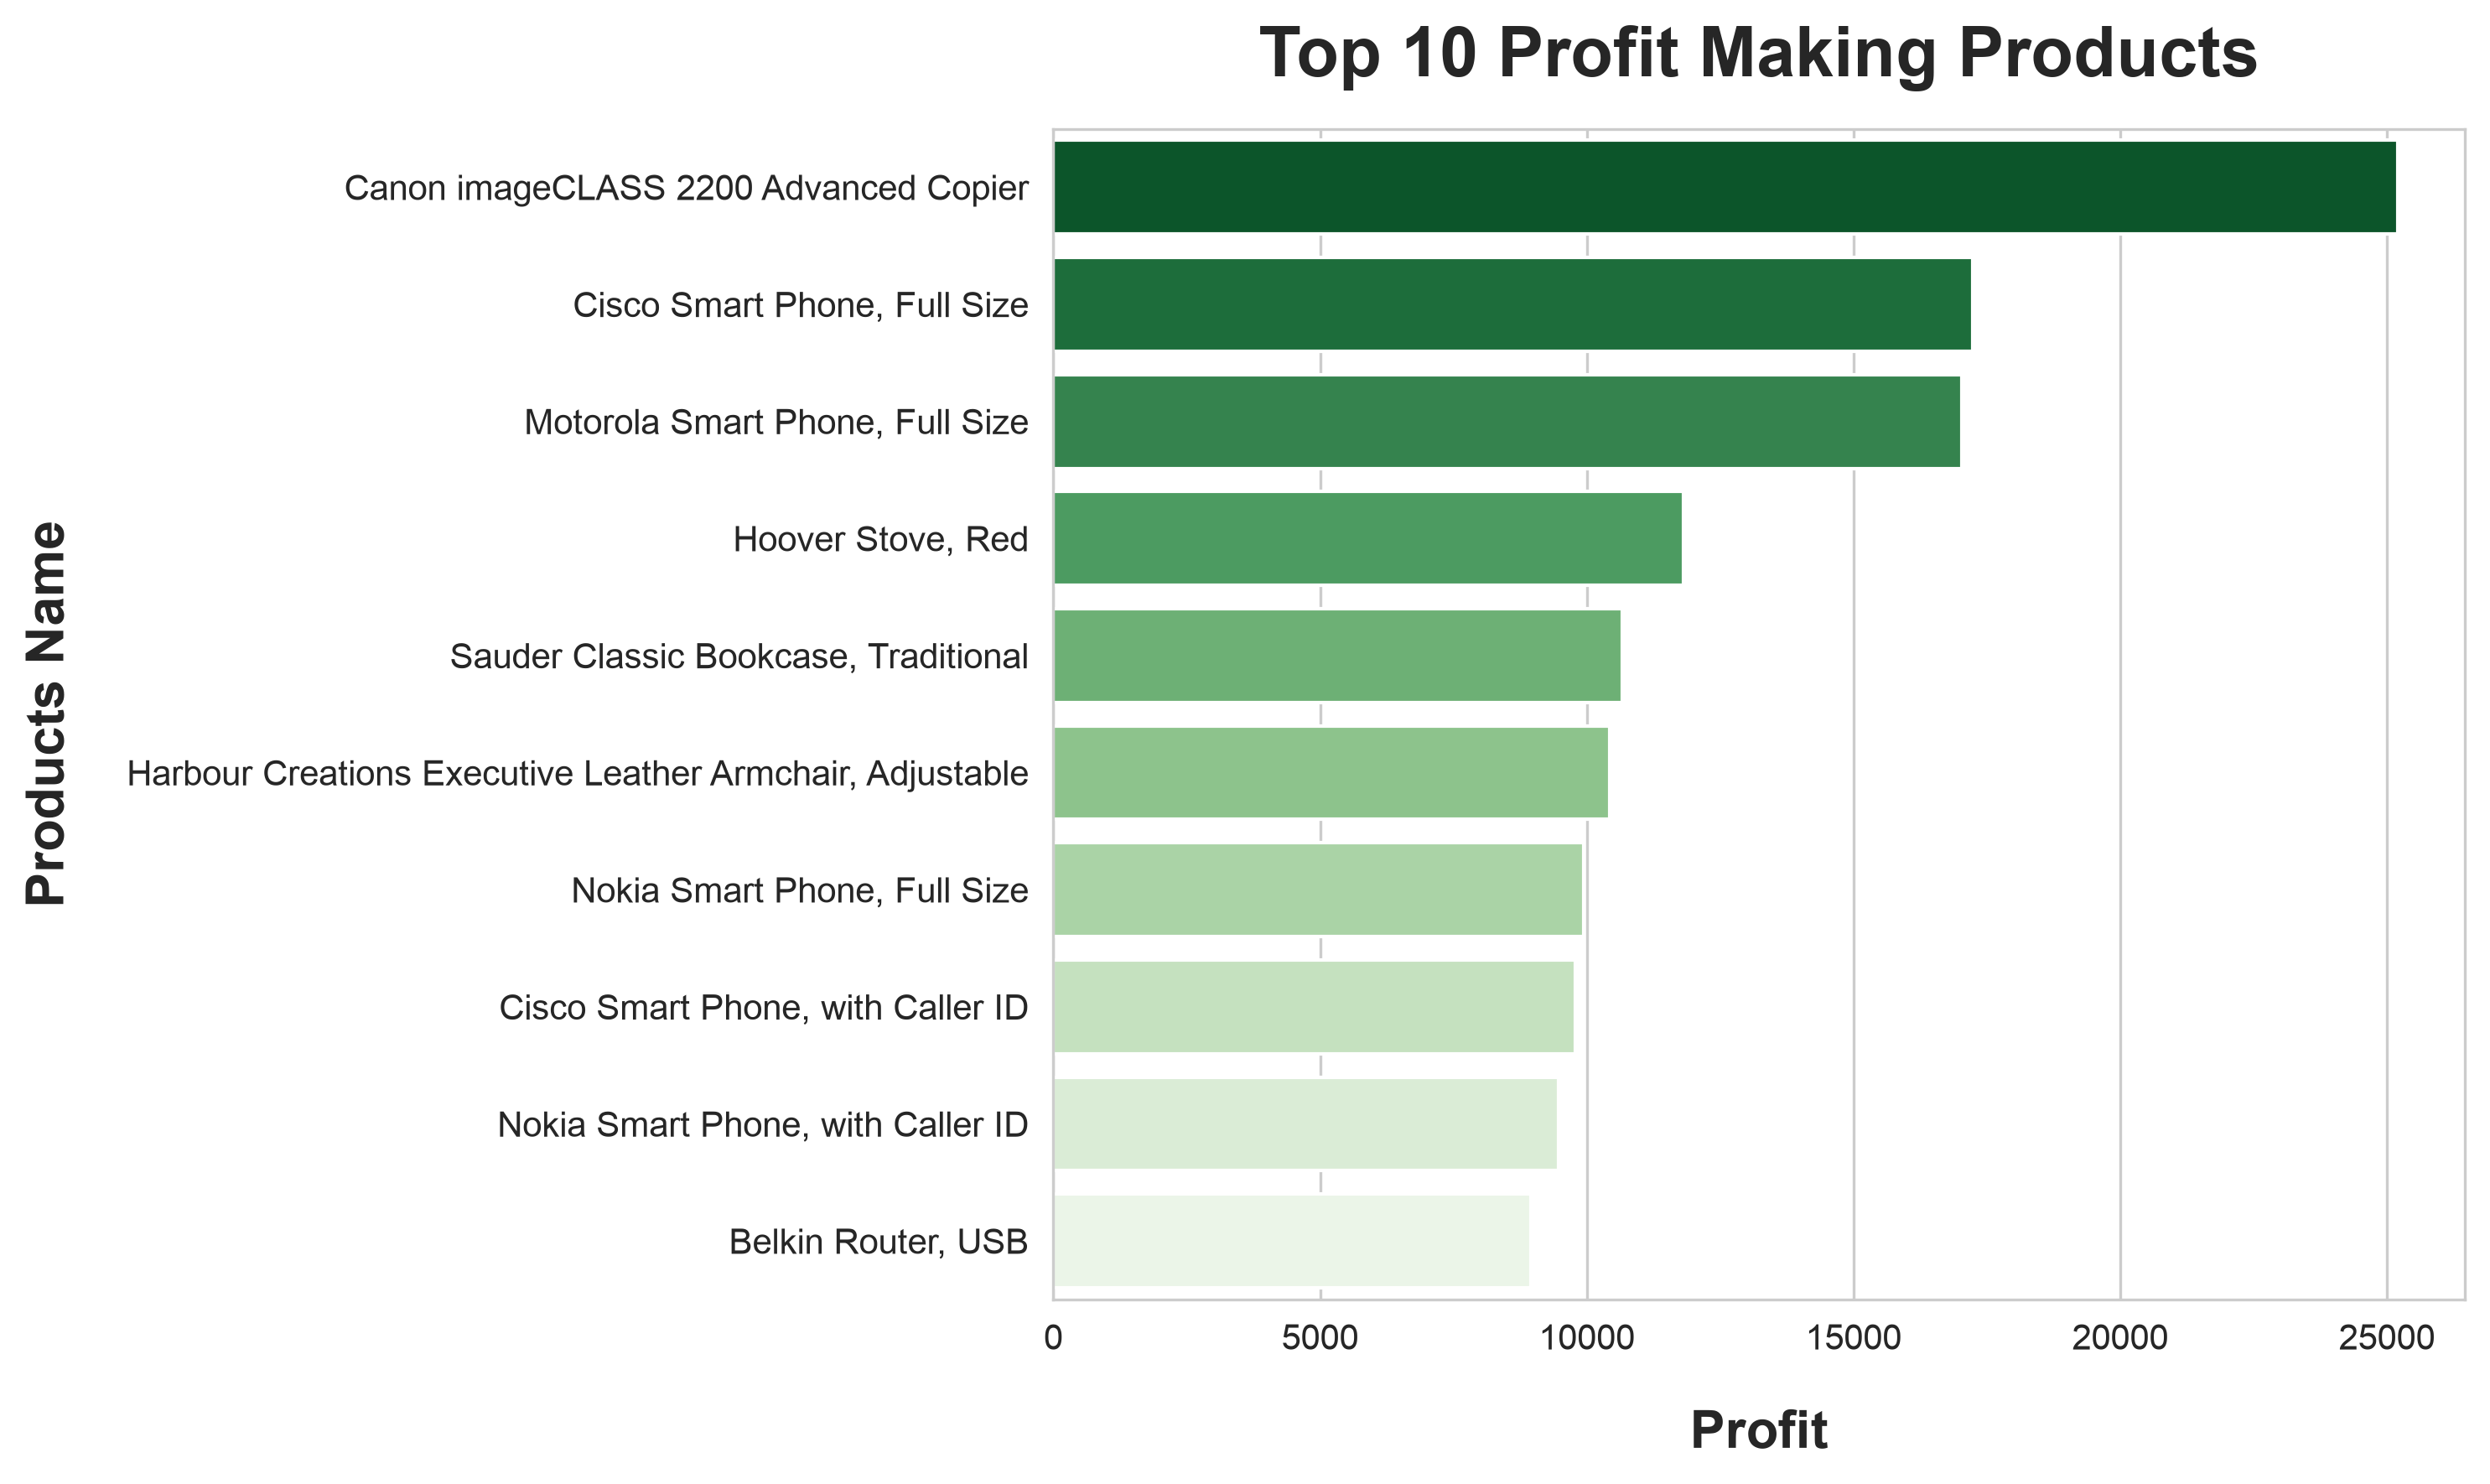

In [34]:
plt.figure(figsize = (10, 6))

sns.barplot(
    data = top_10_profit_making_product,
    x = "Profit",
    y = "Product.Name",
    errorbar = None,
    legend = False,
    palette = "Greens_r",
    hue = "Product.Name"
)

plt.title("Top 10 Profit Making Products", fontsize = 20, fontweight = "bold", pad = 15)

plt.xlabel("Profit", fontsize = 15, fontweight = "bold", labelpad = 15)
plt.ylabel("Products Name", fontsize = 15, fontweight = "bold", labelpad = 15)

plt.tight_layout()

plt.savefig("../images/top_10_profit_making_products.png", dpi = 300, bbox_inches = "tight")
plt.show()

### 📊 Key Observations (Top 10 Profit-Making Products)

* **Leading Profit Contributor:** The advanced copier model emerges as the clear leader, outperforming all other products to bring in the highest total profit for the business.
* **Technology and Communication Dominance:** Smart phones from various major brands occupy a substantial portion of the list, proving to be highly successful revenue lines.
* **Supporting High-Value Items:** Bulky household and office assets like stoves, bookcases, and executive chairs also show strong performance, rounding out the top tier of profitable products.

**💡 Summary:** High-end technology gear, specifically copiers and mobile communication devices, serve as the primary engines driving company profitability, making them critical for sustained business growth.


## 💸 Profit Margin

In [59]:
margin_df = df.groupby("Category")[["Profit", "Sales"]].sum().reset_index()

margin_df["Profit Margin"] = (margin_df["Profit"]/margin_df["Sales"]) * 100 

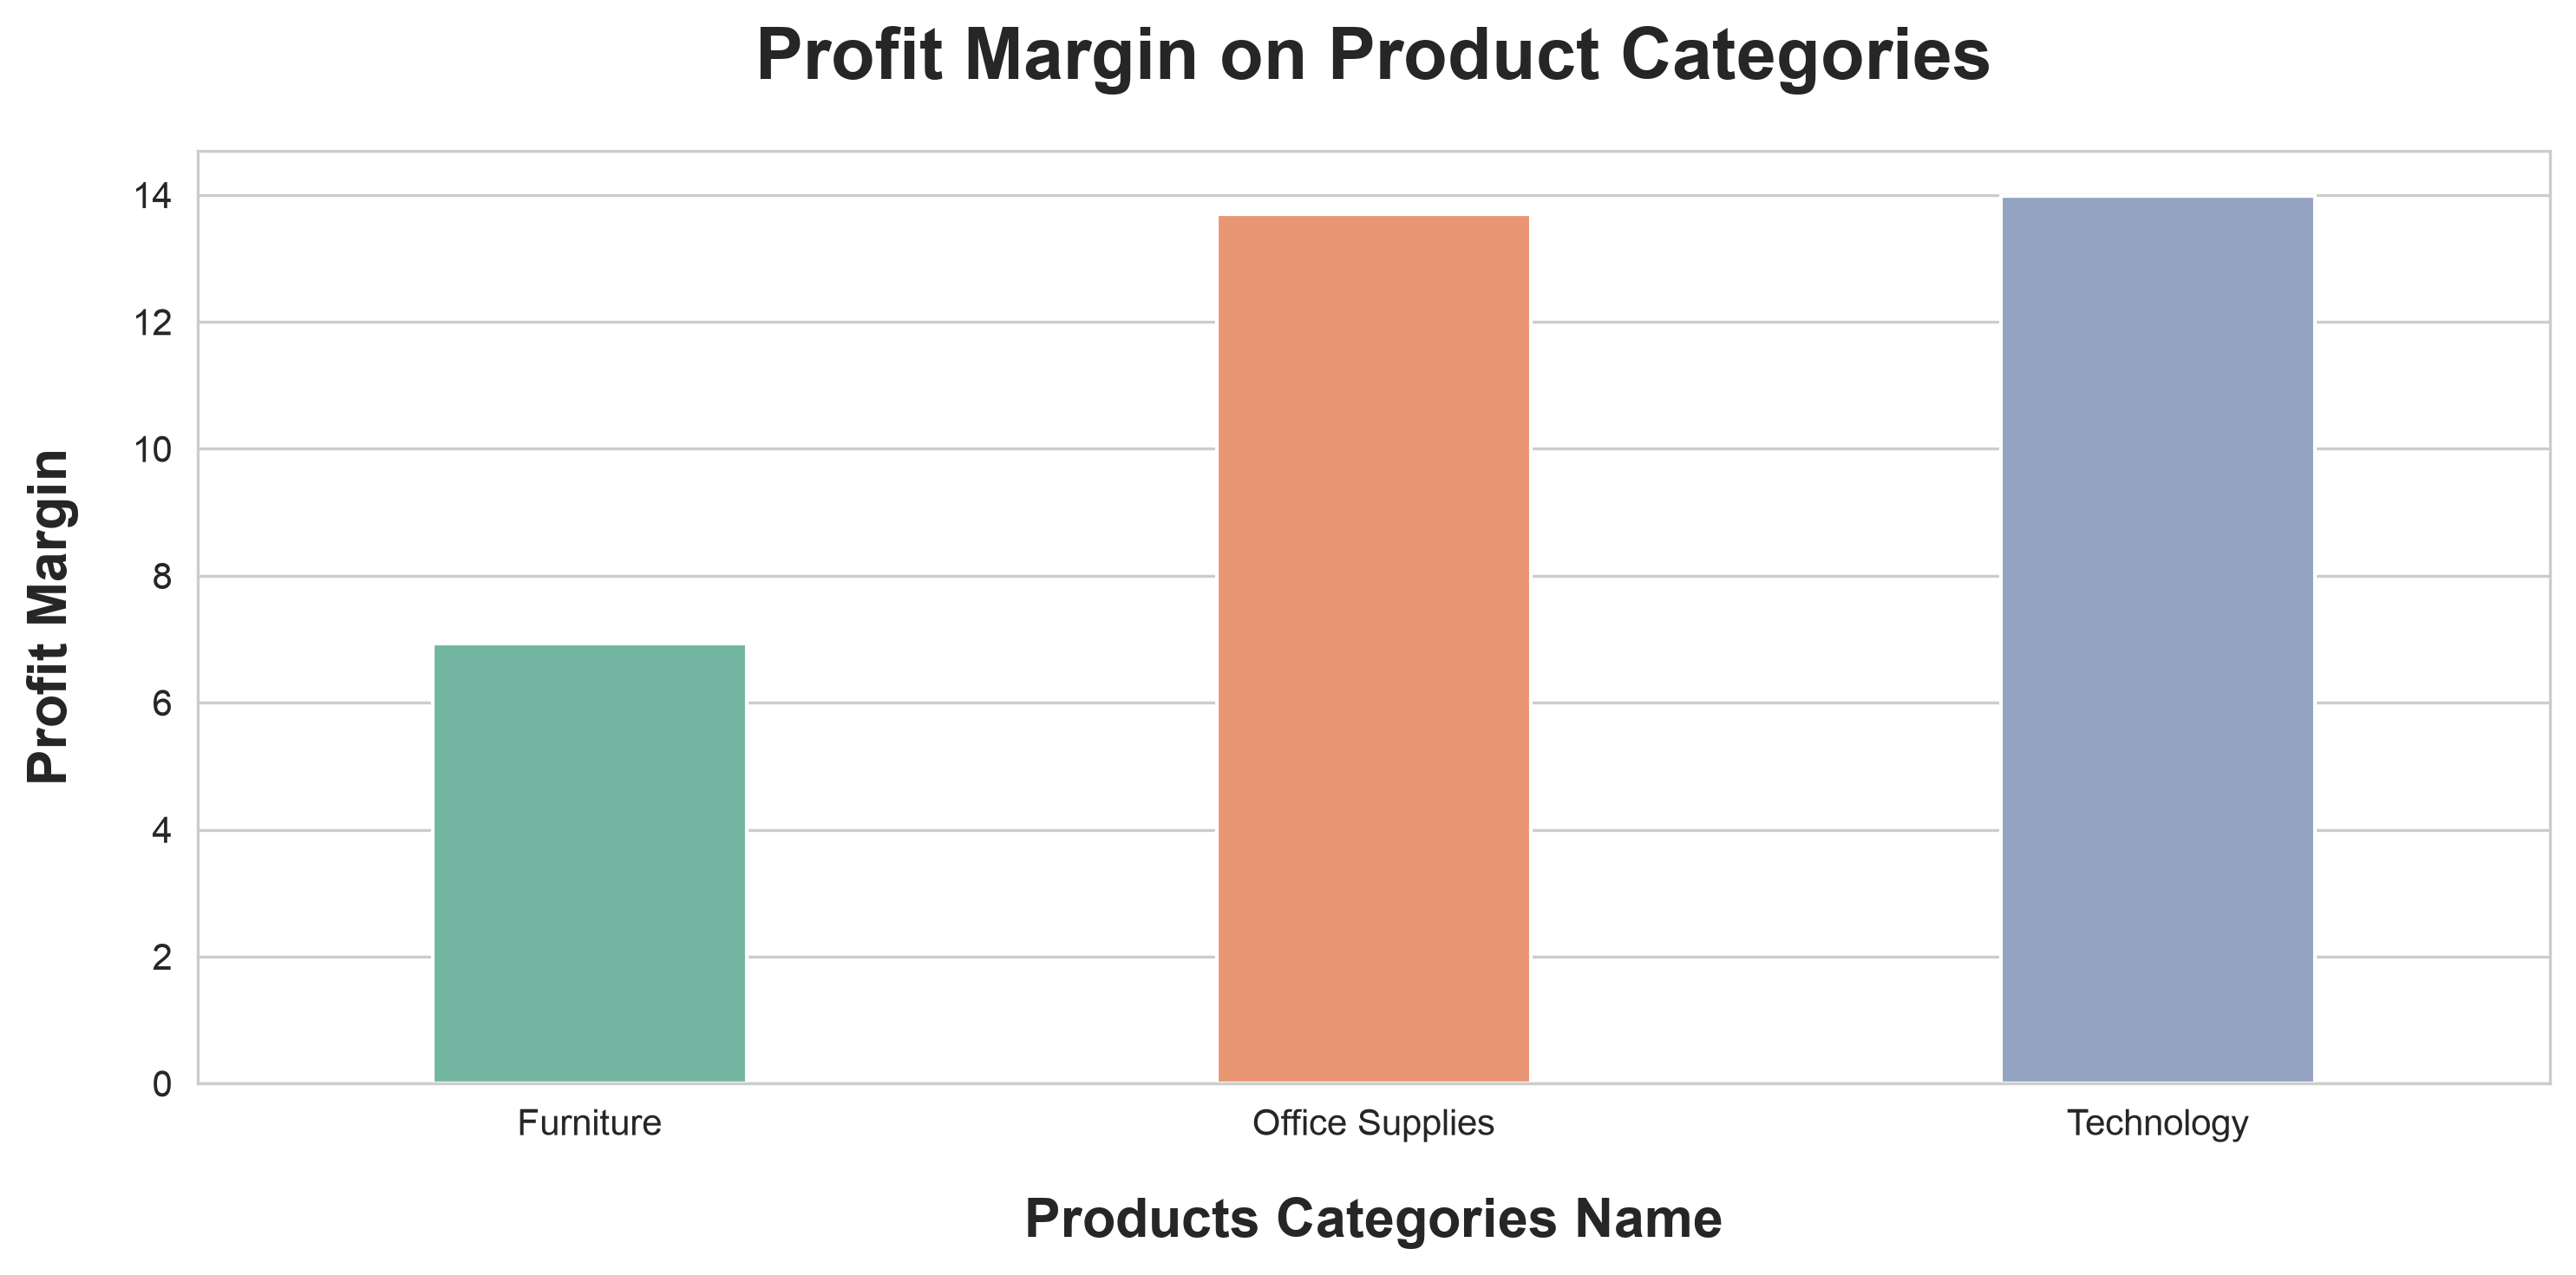

In [51]:
plt.figure(figsize = (10, 5))

sns.barplot(
    data = margin_df,
    x = "Category",
    y = "Profit Margin",
    errorbar = None,
    palette = "Set2",
    hue = "Category",
    legend = False,
    width = 0.4
)
plt.title("Profit Margin on Product Categories", fontsize = 20, fontweight = "bold", pad = 20)

plt.ylabel("Profit Margin", fontsize = 15, fontweight = "bold", labelpad = 15)
plt.xlabel("Products Categories Name", fontsize = 15, fontweight = "bold", labelpad = 15)

plt.tight_layout()

plt.savefig("../images/profit_margin_on_product_categories.png", dpi = 300, bbox_inches = "tight")
plt.show()

### 📊 Key Observations (Profit Margin on Categories)

* **Highest Efficiency:** The **Technology** category achieves the highest profit margin among all segments, making it the most efficient generator of net returns relative to its sales volume.
* **Close Competitor:** **Office Supplies** follows very closely behind Technology, showing a strong and healthy profit margin that is nearly on par with the top performer.
* **Least Efficient Segment:** **Furniture** stands at the bottom of the list with a significantly lower profit margin, indicating that a smaller portion of its total revenue translates into actual profit.

**💡 Summary:** While **Technology** and **Office Supplies** are highly profitable and efficient, the **Furniture** category requires a strategy overhaul to improve its low margin conversion rate.


### 📊 Key Observations (Profit Margin on Categories)

* **Highest Efficiency:** The **Technology** category achieves the highest profit margin among all segments, making it the most efficient generator of net returns relative to its sales volume.
* **Close Competitor:** **Office Supplies** follows very closely behind Technology, showing a strong and healthy profit margin that is nearly on par with the top performer.
* **Least Efficient Segment:** **Furniture** stands at the bottom of the list with a significantly lower profit margin, indicating that a smaller portion of its total revenue translates into actual profit.

**💡 Summary:** While **Technology** and **Office Supplies** are highly profitable and efficient, the **Furniture** category requires a strategy overhaul to improve its low margin conversion rate.
